# Antibody Developability Optimization — Pipeline

Generates novel HCDR3 variants of therapeutic antibodies with better predicted
developability (HIC and AC-SINS) using conditional flow matching in AbLang2
CDR3 embedding space.

**Run order:** Execute every section top-to-bottom. Sections 2 and 4 are slow
(~15 min each on T4) but cache results to Drive so they only run once.

### Architecture summary
| Component | What it does |
|---|---|
| AbLang2 (frozen) | Extracts CDR3, framework, and full-sequence embeddings |
| Ridge oracle | Predicts HIC and AC-SINS from full-sequence embeddings |
| Flow model | Generates candidate CDR3 embedding targets per parent framework |
| AbLang2 masked pass | Produces natural CDR3 sequences for the parent framework |
| Distance matrix | Selects sequences whose embeddings are closest to flow targets |
| Oracle (Phase 3) | Scores final assembled sequences — never intermediate ODE states |

> Runtime → Change runtime type → **T4 GPU** before running.

---
## Section 0 — Installs & Imports

In [22]:
# Install required packages.
# Run this cell once. If Colab prompts to restart the runtime, do so
# and then skip back to this cell (it will already be installed).
!pip install -q ablang2        # AbLang2 antibody language model
!pip install -q torchcfm       # Conditional flow matching training loop
!pip install -q torchdiffeq    # ODE integrator for Phase 1 sampling
!pip install -q scikit-learn scipy matplotlib seaborn joblib
!pip install peft transformers accelerate bitsandbytes
!pip install fastparquet pyarrow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 893.0/893.0 kB 16.1 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.7/36.7 MB 39.6 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 31.0 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [fastparquet] [cramjam]


In [23]:
import os, re, warnings, json
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
from scipy.stats import spearmanr, pearsonr, ttest_rel, ks_2samp
from scipy.spatial.distance import cdist as scipy_cdist
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cross_decomposition import PLSRegression
from sklearn.model_selection import KFold
import joblib

from torchcfm.conditional_flow_matching import ConditionalFlowMatcher
from torchdiffeq import odeint

# For LoRA fine-tuning (optional)
from peft import LoraConfig, TaskType, get_peft_model

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE}')
torch.manual_seed(42)
np.random.seed(42)

Device: cpu


In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

# ── Directory and file paths ──────────────────────────────────────────────────
# All cached numpy arrays, model checkpoints, and eval inputs are saved here.
# If you move the project, update PROJECT_DIR and everything else follows.
PROJECT_DIR = '/content/drive/MyDrive/project'
EVAL_DIR    = f'{PROJECT_DIR}/eval_inputs'   # saved artifacts for eval notebook
DATA_PATH   = f'{PROJECT_DIR}/GDPa1_v1.2_20250814.csv'

os.makedirs(PROJECT_DIR, exist_ok=True)
os.makedirs(EVAL_DIR,    exist_ok=True)

# Convenience function so cached file paths are always consistent
CACHE = lambda name: f'{PROJECT_DIR}/{name}'

# ── OAS Pretraining Paths & Hyperparameters ───────────────────────────────────
OAS_DIR             = f'{PROJECT_DIR}/oas_paired'       # folder with downloaded .csv.gz
OAS_CACHE_DIR       = f'{PROJECT_DIR}/oas_cache'        # cached embeddings
OAS_PRETRAIN_EPOCHS = 5          # pretraining epochs on OAS
OAS_PRETRAIN_BS     = 256        # batch size for OAS flow training
OAS_PRETRAIN_LR     = 1e-3       # learning rate for OAS pretraining
OAS_FINETUNE_LR     = 1e-4       # learning rate for GDPa1 fine-tuning
OAS_MAX_SEQUENCES   = 2_000_000  # cap on OAS sequences after filtering
OAS_EMBED_BATCH     = 16         # AbLang2 batch size for OAS embedding

os.makedirs(OAS_DIR,       exist_ok=True)
os.makedirs(OAS_CACHE_DIR, exist_ok=True)

# ── Dataset column names ──────────────────────────────────────────────────────
# Defined once here so renaming a column only requires one edit.
COL_VH    = 'vh_protein_sequence'
COL_VL    = 'vl_protein_sequence'
COL_HIC   = 'HIC'
COL_SINS  = 'AC-SINS_pH7.4'
COL_FOLD  = 'hierarchical_cluster_fold'
COL_AHO_H = 'heavy_aligned_aho'
COL_AHO_L = 'light_aligned_aho'
COL_NAME  = 'antibody_name'

# ── Key hyperparameters ───────────────────────────────────────────────────────
TEST_FOLD       = 1      # fold held out as test set (never used during training)
N_FLOW_SAMPLES  = 50     # independent noise seeds per test antibody in Phase 1
N_ODE_STEPS     = 100    # Euler integration steps for ODE
M_SEQUENCES     = 20     # sequences sampled from AbLang2 masked pass in Phase 2
TEMPERATURE     = 1.0    # sampling temperature for AbLang2 (1.0 = raw distribution)
TOP_K_SELECT    = 5      # top-k (flow_target, sequence) pairs passed to oracle
FLOW_EPOCHS     = 1000   # training epochs for flow model
CURRENT_SIGMA   = 0.5    # CFM noise parameter (higher = less deterministic)
PLS_COMPONENTS  = 10     # PLS dimensionality for flow model input space
AA_VOCAB        = list('ACDEFGHIKLMNPQRSTVWY')
AA_TO_IDX       = {aa: i for i, aa in enumerate(AA_VOCAB)}
ABLANG_MASK     = '*'    # AbLang2's mask token character

---
## Section 1 — Data Loading, CDR3 Extraction & Split

### 1a — Load dataset

In [6]:
df = pd.read_csv(DATA_PATH)
print(f'Raw rows: {df.shape[0]}')

# Drop antibodies missing either chain sequence — we need both for AbLang2
df = df.dropna(subset=[COL_VH, COL_VL]).reset_index(drop=True)
print(f'After dropping missing VH/VL: {len(df)}')

print('\nPrimary oracle target missingness (will be imputed with training median):')
print(df[[COL_HIC, COL_SINS]].isna().sum())

Raw rows: 246
After dropping missing VH/VL: 246

Primary oracle target missingness (will be imputed with training median):
HIC              4
AC-SINS_pH7.4    4
dtype: int64


### 1b — HCDR3 extraction via AHo numbering

AHo CDR-H3 occupies positions 107–138 (1-indexed) = indices 106–137 (0-indexed).
The `heavy_aligned_aho` column contains the VH sequence aligned to AHo, with
dashes (`-`) for positions this antibody does not have a residue at.

We walk the aligned string and record which positions in the **ungapped** raw VH
sequence fall inside CDR3 vs framework. These integer index lists are reused
later to: (1) extract sub-embeddings, (2) place AbLang2 mask tokens, (3) splice
generated CDR3 sequences back into the parent framework.

In [7]:
AHO_CDR3_START = 106   # 0-indexed inclusive
AHO_CDR3_END   = 138   # 0-indexed exclusive (positions 106..137)

def get_cdr3_and_fw_indices(aligned_aho_seq):
    """
    Parse an AHo-aligned VH string and return two lists of integer indices
    into the UNGAPPED raw VH sequence.

    cdr3_idx : positions inside AHo CDR-H3 window (106-137)
    fw_idx   : all other positions (framework regions FR1-FR4)

    How it works: walk character by character through the aligned string.
    A dash means no residue at this AHo position for this antibody — skip it.
    Any real amino acid increments the raw-position counter and gets bucketed
    into CDR3 or framework based on its AHo position.
    """
    cdr3_idx, fw_idx = [], []
    raw_pos = 0
    for aho_pos, char in enumerate(aligned_aho_seq):
        if char == '-':
            continue
        if AHO_CDR3_START <= aho_pos < AHO_CDR3_END:
            cdr3_idx.append(raw_pos)
        else:
            fw_idx.append(raw_pos)
        raw_pos += 1
    return cdr3_idx, fw_idx

# Extract CDR3 sequences and index lists for all antibodies
hcdr3_seqs, h_cdr3_idx_list, h_fw_idx_list = [], [], []
for _, row in df.iterrows():
    if pd.isna(row[COL_AHO_H]):
        hcdr3_seqs.append(None)
        h_cdr3_idx_list.append([])
        h_fw_idx_list.append([])
        continue
    cdr3_idx, fw_idx = get_cdr3_and_fw_indices(row[COL_AHO_H])
    seq = ''.join(row[COL_VH][i] for i in cdr3_idx if i < len(row[COL_VH]))
    hcdr3_seqs.append(seq if seq else None)
    h_cdr3_idx_list.append(cdr3_idx)
    h_fw_idx_list.append(fw_idx)

df['hcdr3_sequence'] = hcdr3_seqs
df['h_cdr3_idx']     = h_cdr3_idx_list
df['h_fw_idx']       = h_fw_idx_list
df['hcdr3_len']      = df['hcdr3_sequence'].apply(
    lambda s: len(s) if isinstance(s, str) else 0)

valid = df['hcdr3_sequence'].notna() & (df['hcdr3_sequence'] != '')
print(f'Antibodies with valid HCDR3: {valid.sum()} / {len(df)}')
print(df.loc[valid, 'hcdr3_len'].describe().round(1))

Antibodies with valid HCDR3: 246 / 246
count    246.0
mean      12.5
std        3.2
min        5.0
25%       10.0
50%       12.0
75%       14.0
max       23.0
Name: hcdr3_len, dtype: float64


### 1c — Train/test split and CDR3 length analysis

Train (folds 2-5): 196  |  Test (fold 1): 50
CDR3 length KS test: stat=0.050  p=1.000
✓ compatible

CDR3 length distribution:
 length  train  test  train_%  test_%
      5      3     0      1.5     0.0
      6      4     0      2.0     0.0
      7      1     1      0.5     2.0
      8      8     3      4.1     6.0
      9     17     5      8.7    10.0
     10     17     5      8.7    10.0
     11     22     6     11.2    12.0
     12     35     6     17.9    12.0
     13     23     7     11.7    14.0
     14     21     8     10.7    16.0
     15     14     3      7.1     6.0
     16     10     3      5.1     6.0
     17      4     0      2.0     0.0
     18      7     1      3.6     2.0
     19      6     1      3.1     2.0
     20      1     1      0.5     2.0
     22      1     0      0.5     0.0
     23      2     0      1.0     0.0


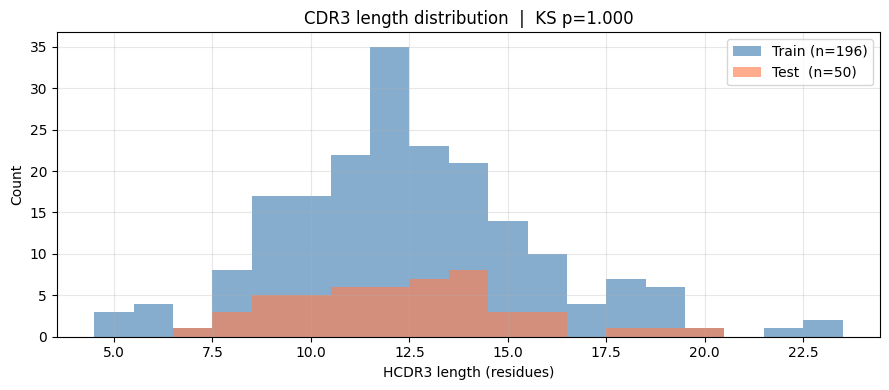

In [8]:
# Split using pre-computed hierarchical cluster folds.
# Fold 1 = test (~49 antibodies), folds 2-5 = train (~197 antibodies).
# The clustering ensures antibodies with similar sequences land in the same fold,
# so holding out fold 1 prevents the model from memorising the training sequences.
train_mask = df[COL_FOLD] != TEST_FOLD
test_mask  = df[COL_FOLD] == TEST_FOLD
train_idx  = df.index[train_mask].values
test_idx   = df.index[test_mask].values
print(f'Train (folds 2-5): {len(train_idx)}  |  Test (fold 1): {len(test_idx)}')

# ── CDR3 length distribution ──────────────────────────────────────────────────
# Important: Phase 2 places exactly len(parent_CDR3) mask tokens, so generated
# sequences are guaranteed the same length as the parent. Knowing the length
# distribution tells us whether the train/test split is balanced in this respect.
train_lens = df.loc[train_idx, 'hcdr3_len'].values
test_lens  = df.loc[test_idx,  'hcdr3_len'].values
train_lens = train_lens[train_lens > 0]
test_lens  = test_lens[test_lens > 0]

ks_stat, ks_p = ks_2samp(train_lens, test_lens)
print(f'CDR3 length KS test: stat={ks_stat:.3f}  p={ks_p:.3f}')
print('✓ compatible' if ks_p >= 0.05 else '⚠ distributions differ')

# Per-length count table
all_lens   = sorted(set(train_lens) | set(test_lens))
len_table  = pd.DataFrame({
    'length':   all_lens,
    'train':    [(train_lens == l).sum() for l in all_lens],
    'test':     [(test_lens  == l).sum() for l in all_lens],
})
len_table['train_%'] = (len_table['train'] / len(train_lens) * 100).round(1)
len_table['test_%']  = (len_table['test']  / len(test_lens)  * 100).round(1)
print('\nCDR3 length distribution:')
print(len_table[len_table[['train','test']].sum(axis=1) > 0].to_string(index=False))

# Histogram comparing train vs test length distributions
bins = np.arange(min(all_lens) - 0.5, max(all_lens) + 1.5, 1)
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(train_lens, bins=bins, alpha=0.65, color='steelblue',
        label=f'Train (n={len(train_lens)})')
ax.hist(test_lens,  bins=bins, alpha=0.65, color='coral',
        label=f'Test  (n={len(test_lens)})')
ax.set(xlabel='HCDR3 length (residues)', ylabel='Count',
       title=f'CDR3 length distribution  |  KS p={ks_p:.3f}')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(CACHE('cdr3_length_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()

### 1d — Chemical liability annotation

In [ ]:
# Scan each HCDR3 for chemical degradation motifs.
# NG = deamidation, DG/DS = isomerization, NxS/NxT = N-linked glycosylation.
# These motifs are engineering liabilities in therapeutic antibodies.
# We report Spearman correlation with assay values to verify they encode
# developability signal in this dataset.
LIABILITY_PATTERNS = {
    'NG':  re.compile(r'NG'),
    'DG':  re.compile(r'DG'),
    'DS':  re.compile(r'DS'),
    'NxS': re.compile(r'N[^P]S'),
    'NxT': re.compile(r'N[^P]T'),
}

def count_liabilities(seq):
    if not isinstance(seq, str) or not seq:
        return 0, {}
    counts = {n: len(p.findall(seq)) for n, p in LIABILITY_PATTERNS.items()}
    return sum(counts.values()), counts

total_liabs, liab_details = zip(*[count_liabilities(s) for s in df['hcdr3_sequence']])
df['liability_count']  = total_liabs
df['liability_detail'] = liab_details

print('Liability count distribution:')
print(df['liability_count'].value_counts().sort(index=True))
for col in [COL_HIC, COL_SINS]:
    sub = df[[col, 'liability_count']].dropna()
    rho, p_val = spearmanr(sub['liability_count'], sub[col])
    print(f'Spearman ρ(liability_count, {col}): {rho:+.3f}  p={p_val:.3f}')

Liability count distribution:
liability_count
0    198
1     46
2      2
Name: count, dtype: int64
Spearman ρ(liability_count, HIC): +0.069  p=0.284
Spearman ρ(liability_count, AC-SINS_pH7.4): -0.089  p=0.166


### 1e — HIC/AC-SINS imputation and distribution check

In [10]:
# Impute the ~3 missing HIC and AC-SINS values using the TRAINING-SET median.
# Computing the median on the full dataset would leak fold-1 statistics
# into the normalization. We compute on folds 2-5 only and apply everywhere.
def impute_train_median(df, col, train_idx):
    vals   = df[col].copy().astype(float)
    median = float(np.nanmedian(vals.values[train_idx]))
    return vals.fillna(median).values, median

y_hic,  hic_med  = impute_train_median(df, COL_HIC,  train_idx)
y_sins, sins_med = impute_train_median(df, COL_SINS, train_idx)

y_hic_train,  y_hic_test  = y_hic[train_idx],  y_hic[test_idx]
y_sins_train, y_sins_test = y_sins[train_idx], y_sins[test_idx]

print(f'HIC  imputation median: {hic_med:.3f}')
print(f'SINS imputation median: {sins_med:.3f}')

# KS test: verify fold 1 distribution is not drastically different from training.
# If p < 0.05 consider using fold 2 as the test set instead.
for col, ytr, yte in [(COL_HIC, y_hic_train, y_hic_test),
                       (COL_SINS, y_sins_train, y_sins_test)]:
    s, p_val = ks_2samp(ytr, yte)
    flag = '✓' if p_val >= 0.05 else '⚠ consider fold 2'
    print(f'KS {col}: stat={s:.3f}  p={p_val:.3f}  {flag}')

HIC  imputation median: 2.735
SINS imputation median: 1.625
KS HIC: stat=0.137  p=0.400  ✓
KS AC-SINS_pH7.4: stat=0.092  p=0.853  ✓


---
## Section 2 — AbLang2 Embedding Extraction

Three embeddings are computed per antibody from the **frozen** AbLang2 model:

| Embedding | AbLang2 mode | Used for |
|---|---|---|
| `cdr3_embs` | rescoding, mean-pool CDR3 positions | Flow model target distribution |
| `fw_embs` | rescoding with CDR3 **masked to `*`** first | Flow model conditioning |
| `full_embs` | seqcoding (mean-pool full VH+VL) | Oracle training and scoring |

**Why mask the CDR3 before computing the framework embedding?**
AbLang2 is a transformer — every position attends to every other position.
Without masking, the framework hidden states encode CDR3 information via attention.
At inference, a conditioning signal that leaks CDR3 information would let the
flow model reconstruct the original CDR3 rather than generate a novel one.
Replacing CDR3 positions with `*` before the forward pass eliminates this leak.

In [11]:
import ablang2

print('Loading AbLang2 paired model (frozen)...')
ablang = ablang2.pretrained(model_to_use='ablang2-paired',
                            random_init=False, ncpu=1, device=DEVICE)
ablang.freeze()  # never fine-tune — only 197 training points
print('AbLang2 loaded.')

Loading AbLang2 paired model (frozen)...
AbLang2 loaded.


### 2a — CDR3 embeddings

In [12]:
# Mean-pool the AbLang2 hidden states at CDR3 positions only.
# These are the TARGETS for flow model training — the model learns to
# map Gaussian noise toward this distribution of CDR3 embeddings.
CDR3_CACHE = CACHE('cdr3_embeddings.npy')

if os.path.exists(CDR3_CACHE):
    cdr3_embs = np.load(CDR3_CACHE)
    print(f'Loaded CDR3 embeddings from cache: {cdr3_embs.shape}')
else:
    print('Computing CDR3 embeddings (run once, ~10 min on T4)...')
    BATCH, cdr3_list = 8, []
    for i in range(0, len(df), BATCH):
        rows = df.iloc[i:i+BATCH]
        seqs = list(zip(rows[COL_VH], rows[COL_VL]))
        with torch.no_grad():
            reps = ablang(seqs, mode='rescoding')  # per-residue hidden states
        for j, row in enumerate(rows.itertuples()):
            hidden = np.array(reps[j])
            vh_len = len(row.vh_protein_sequence)
            h_hid  = hidden[:vh_len]  # VH portion only
            valid  = [k for k in row.h_cdr3_idx if k < len(h_hid)]
            cdr3_list.append(h_hid[valid].mean(0) if valid else np.zeros(480))
        if i % 40 == 0: print(f'  {min(i+BATCH, len(df))}/{len(df)}')
    cdr3_embs = np.vstack(cdr3_list)
    np.save(CDR3_CACHE, cdr3_embs)
    print(f'Saved: {cdr3_embs.shape}')

CDR3_DIM = cdr3_embs.shape[1]  # 480

Loaded CDR3 embeddings from cache: (246, 480)


### 2b — Masked framework embeddings

In [13]:
FW_CACHE = CACHE('fw_masked_embeddings.npy')

def mask_cdr3(vh_seq, cdr3_idx):
    """Replace CDR3 positions with AbLang2 mask token before forward pass."""
    chars = list(vh_seq)
    for i in cdr3_idx:
        if i < len(chars): chars[i] = ABLANG_MASK
    return ''.join(chars)

if os.path.exists(FW_CACHE):
    fw_embs = np.load(FW_CACHE)
    print(f'Loaded FW embeddings from cache: {fw_embs.shape}')
else:
    print('Computing masked-framework embeddings...')
    BATCH, fw_list = 8, []
    for i in range(0, len(df), BATCH):
        rows = df.iloc[i:i+BATCH]
        # Mask CDR3 residues in each VH before the forward pass
        masked_seqs = [(mask_cdr3(r.vh_protein_sequence, r.h_cdr3_idx),
                        r.vl_protein_sequence)
                       for r in rows.itertuples()]
        with torch.no_grad():
            reps = ablang(masked_seqs, mode='rescoding')
        for j, row in enumerate(rows.itertuples()):
            hidden = np.array(reps[j])
            vh_len = len(row.vh_protein_sequence)
            vl_len = len(row.vl_protein_sequence)
            n_ex   = hidden.shape[0] - vh_len - vl_len
            h_hid  = hidden[:vh_len]
            l_hid  = hidden[vh_len + n_ex:]
            # Framework = non-CDR3 VH positions + all VL positions
            fw_h = h_hid[row.h_fw_idx].mean(0) if row.h_fw_idx else np.zeros(480)
            vl_v = list(range(min(vl_len, l_hid.shape[0])))
            fw_l = l_hid[vl_v].mean(0) if vl_v else np.zeros(480)
            fw_list.append((fw_h + fw_l) / 2.0)
        if i % 40 == 0: print(f'  {min(i+BATCH, len(df))}/{len(df)}')
    fw_embs = np.vstack(fw_list)
    np.save(FW_CACHE, fw_embs)
    print(f'Saved: {fw_embs.shape}')

FW_DIM = fw_embs.shape[1]

Loaded FW embeddings from cache: (246, 480)


### 2c - Full-sequence embeddings (oracle input)

In [14]:
# seqcoding returns one 480d vector per antibody (mean-pool over full VH+VL).
# HIC and AC-SINS are whole-molecule properties — CDR3-only embeddings have
# weaker predictive power. The oracle needs the full sequence representation.
FULL_CACHE = CACHE('full_embeddings.npy')

if os.path.exists(FULL_CACHE):
    full_embs = np.load(FULL_CACHE)
    print(f'Loaded full embeddings from cache: {full_embs.shape}')
else:
    print('Computing full-sequence embeddings...')
    BATCH, full_list = 16, []
    for i in range(0, len(df), BATCH):
        rows = df.iloc[i:i+BATCH]
        seqs = list(zip(rows[COL_VH], rows[COL_VL]))
        with torch.no_grad():
            emb = ablang(seqs, mode='seqcoding')
        full_list.append(emb if isinstance(emb, np.ndarray)
                          else emb.cpu().numpy())
        if i % 64 == 0: print(f'  {min(i+BATCH, len(df))}/{len(df)}')
    full_embs = np.vstack(full_list)
    np.save(FULL_CACHE, full_embs)
    print(f'Saved: {full_embs.shape}')

FULL_DIM = full_embs.shape[1]
print(f'Dims — CDR3: {CDR3_DIM}, FW: {FW_DIM}, Full: {FULL_DIM}')

Loaded full embeddings from cache: (246, 480)
Dims — CDR3: 480, FW: 480, Full: 480


### 2d — Embedding space analysis

Three diagnostics that should be run before training:
1. **Intrinsic dimensionality**: how many PCA components explain 90% of CDR3 variance?
2. **Developability gradient**: do PC1–PC2 show HIC/AC-SINS structure? (usually no — developability directions are in higher PCs)
3. **Test set position**: do fold-1 antibodies fall inside the training distribution?

CDR3 embedding intrinsic dimensionality:
  9 PCs explain 50% variance
  51 PCs explain 90% variance
  (Full space = 480d — effective dim is much lower)


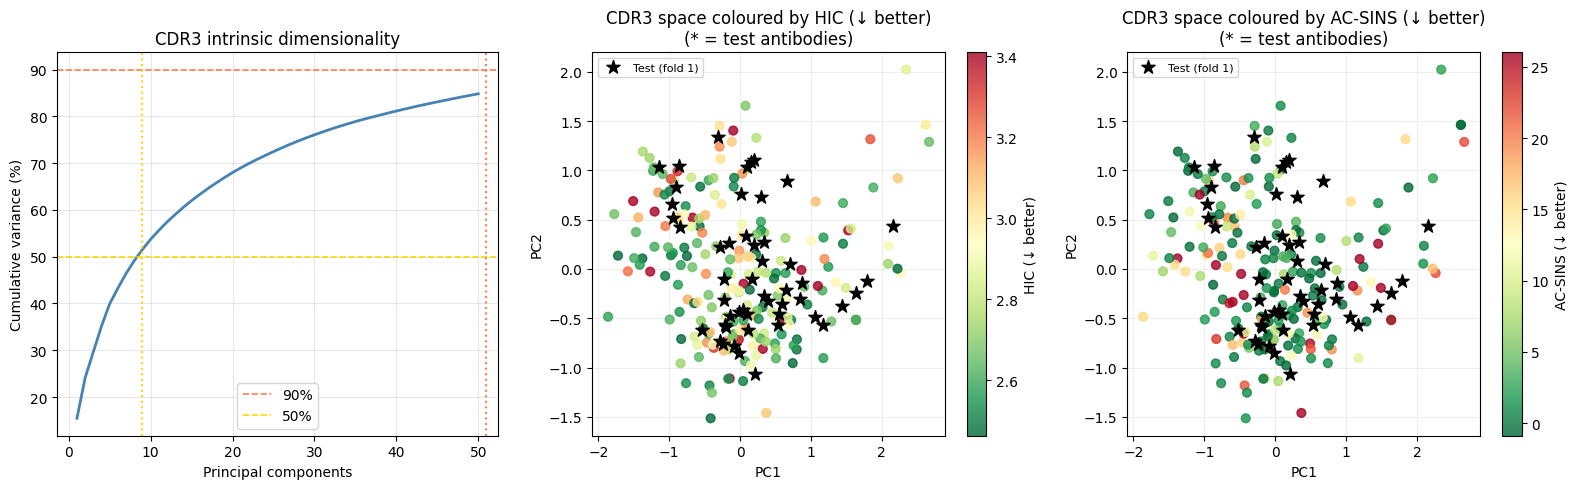

Within-train NN dist (95th pctile): 1.81
Test NN dist: mean=1.29  median=1.27  max=1.72
✓ All test antibodies within training distribution range


In [15]:
# Fit PCA on training CDR3 embeddings ONLY.
# Using all 246 would leak test-set variance into the PCA directions.
pca = PCA(n_components=50, random_state=42)
pca.fit(cdr3_embs[train_idx])

cumvar = np.cumsum(pca.explained_variance_ratio_)
n_90   = int(np.searchsorted(cumvar, 0.90)) + 1
n_50   = int(np.searchsorted(cumvar, 0.50)) + 1
print(f'CDR3 embedding intrinsic dimensionality:')
print(f'  {n_50} PCs explain 50% variance')
print(f'  {n_90} PCs explain 90% variance')
print(f'  (Full space = {CDR3_DIM}d — effective dim is much lower)')

pc_train = pca.transform(cdr3_embs[train_idx])
pc_test  = pca.transform(cdr3_embs[test_idx])

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Plot 1: cumulative explained variance
ax = axes[0]
ax.plot(range(1, 51), cumvar * 100, lw=2, color='steelblue')
ax.axhline(90, color='coral', ls='--', lw=1.2, label='90%')
ax.axhline(50, color='gold',  ls='--', lw=1.2, label='50%')
ax.axvline(n_90, color='coral', ls=':')
ax.axvline(n_50, color='gold',  ls=':')
ax.set(xlabel='Principal components', ylabel='Cumulative variance (%)',
       title='CDR3 intrinsic dimensionality')
ax.legend(); ax.grid(True, alpha=0.3)

# Plots 2-3: PC1 vs PC2 coloured by HIC and AC-SINS
for ax, (y_tr, label, cmap) in zip(axes[1:], [
        (y_hic_train,  'HIC (↓ better)',      'RdYlGn_r'),
        (y_sins_train, 'AC-SINS (↓ better)',  'RdYlGn_r')]):
    sc = ax.scatter(pc_train[:,0], pc_train[:,1], c=y_tr,
                    cmap=cmap, s=40, alpha=0.8, zorder=2,
                    vmin=np.percentile(y_tr,5), vmax=np.percentile(y_tr,95))
    ax.scatter(pc_test[:,0], pc_test[:,1], c='black',
               marker='*', s=100, label='Test (fold 1)', zorder=3)
    plt.colorbar(sc, ax=ax, label=label)
    ax.set(xlabel='PC1', ylabel='PC2',
           title=f'CDR3 space coloured by {label}\n(* = test antibodies)')
    ax.legend(fontsize=8); ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig(CACHE('embedding_space_analysis.png'), dpi=150, bbox_inches='tight')
plt.show()

# ── Test-set OOD check ────────────────────────────────────────────────────────
# Compute within-training nearest-neighbour distances (excluding self-pairs)
# to define a 'normal' inter-point gap. Flag test antibodies that are farther
# from any training point than the 95th percentile of that gap distribution.
train_pc20 = pc_train[:, :20]
test_pc20  = pc_test[:,  :20]

train_pw = scipy_cdist(train_pc20, train_pc20)
np.fill_diagonal(train_pw, np.inf)  # exclude self-distances
train_nn  = train_pw.min(axis=1)
threshold = np.percentile(train_nn, 95)

nn_dists = scipy_cdist(test_pc20, train_pc20).min(axis=1)
outliers = np.where(nn_dists > threshold)[0]

print(f'Within-train NN dist (95th pctile): {threshold:.2f}')
print(f'Test NN dist: mean={nn_dists.mean():.2f}  '
      f'median={np.median(nn_dists):.2f}  max={nn_dists.max():.2f}')
if len(outliers):
    print(f'OOD test antibodies: {len(outliers)}')
    for i in outliers:
        print(f'  {df.iloc[test_idx[i]][COL_NAME]}')
else:
    print('✓ All test antibodies within training distribution range')

---
## Section 2e — LoRA Encoder Classes

These classes enable optional LoRA fine-tuning of AbLang2 for improved oracle predictions.
Set `USE_LORA_ORACLE = True` in Section 3 to use the fine-tuned oracle instead of Ridge.

In [16]:
from torch.utils.data import Dataset, DataLoader

# LoRA hyperparameters (matching developability_model/ablang2_fine_tuned_GDPa1.ipynb)
LORA_R = 8
LORA_ALPHA = 16
LORA_DROPOUT = 0.1
HEAD_DROPOUT = 0.1
LORA_EPOCHS = 30
LORA_BATCH_SIZE = 8
LORA_LR = 1e-4
LORA_WEIGHT_DECAY = 1e-4


class AbLang2LoRAEncoder(nn.Module):
    """
    Wraps the AbLang2 AbRep encoder and injects LoRA adapters into every
    MultiHeadAttention block (q_proj, k_proj, v_proj, out_proj).
    Returns mean-pooled [B, hidden_size] embeddings ignoring padding tokens.
    """
    LORA_TARGET_MODULES = ["q_proj", "k_proj", "v_proj", "out_proj"]

    def __init__(self, ablang2_model, lora_r=LORA_R, lora_alpha=LORA_ALPHA,
                 lora_dropout=LORA_DROPOUT, freeze_non_lora=True):
        super().__init__()
        self.ablang = ablang2_model
        self.tokenizer = ablang2_model.tokenizer
        self.padding_tkn = ablang2_model.AbLang.AbRep.padding_tkn

        lora_cfg = LoraConfig(
            r=lora_r,
            lora_alpha=lora_alpha,
            lora_dropout=lora_dropout,
            target_modules=self.LORA_TARGET_MODULES,
            bias="none",
            task_type=TaskType.FEATURE_EXTRACTION,
        )
        self.ablang.AbLang = get_peft_model(self.ablang.AbLang, lora_cfg)

        if freeze_non_lora:
            for name, param in self.ablang.AbLang.named_parameters():
                if "lora_" not in name:
                    param.requires_grad_(False)

        n_trainable = sum(p.numel() for p in self.ablang.AbLang.parameters() if p.requires_grad)
        n_total = sum(p.numel() for p in self.ablang.AbLang.parameters())
        print(f"LoRA injected: {n_trainable:,} trainable / {n_total:,} total "
              f"({100 * n_trainable / n_total:.2f}%)")

    def tokenize(self, vh_seqs, vl_seqs, device):
        # For 'ablang2-paired', the tokenizer expects a list of (heavy_seq, light_seq) tuples
        paired_sequences = list(zip(vh_seqs, vl_seqs))
        tokens = self.tokenizer(paired_sequences, pad=True, w_extra_tkns=True)
        return tokens.to(device)

    def forward(self, tokens):
        self.ablang.AbLang.train()
        reps = self.ablang.AbLang.AbRep(tokens)
        hidden = reps.last_hidden_states
        pad_mask = tokens.eq(self.padding_tkn).unsqueeze(-1)
        hidden = hidden.masked_fill(pad_mask, 0.0)
        lengths = (~pad_mask).sum(dim=1).clamp(min=1).float()
        return hidden.sum(dim=1) / lengths


class RegressionHead(nn.Module):
    """Single-target regression head on top of pooled embeddings."""
    def __init__(self, hidden_size, dropout=HEAD_DROPOUT):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(hidden_size, 64),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(64, 1),
        )

    def forward(self, emb):
        return self.net(emb).squeeze(-1)


class AntibodyDataset(Dataset):
    def __init__(self, vh_seqs, vl_seqs, labels):
        super().__init__()
        self.vh = vh_seqs
        self.vl = vl_seqs
        self.labels = labels

    def __len__(self):
        return len(self.vh)

    def __getitem__(self, idx):
        return self.vh[idx], self.vl[idx], self.labels[idx]


def collate_fn(batch):
    vh, vl, labels = zip(*batch)
    return list(vh), list(vl), torch.tensor(labels, dtype=torch.float32)


@torch.no_grad()
def predict_lora(encoder, head, loader, device, target_label_type):
    encoder.ablang.AbLang.eval()
    head.eval()
    all_preds, all_labels = [], []
    for vh, vl, labels_hic, labels_sins in loader: # Unpack all four items
        tokens = encoder.tokenize(vh, vl, device)
        embedding = encoder(tokens)
        preds = head(embedding).cpu().numpy()
        all_preds.append(preds)

        if target_label_type == 'hic':
            all_labels.append(labels_hic.numpy())
        elif target_label_type == 'sins':
            all_labels.append(labels_sins.numpy())
        else:
            raise ValueError("Invalid target_label_type. Must be 'hic' or 'sins'.")

    return np.concatenate(all_preds), np.concatenate(all_labels)

def train_epoch_lora(encoder, head, loader, optimizer, loss_fn, device):
    encoder.ablang.AbLang.train()
    head.train()
    total_loss = 0.0
    for vh, vl, labels in loader:
        tokens = encoder.tokenize(vh, vl, device)
        labels = labels.to(device)
        optimizer.zero_grad()
        emb = encoder(tokens)
        preds = head(emb)
        loss = loss_fn(preds, labels)
        loss.backward()
        nn.utils.clip_grad_norm_(
            list(encoder.parameters()) + list(head.parameters()), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item() * len(labels)
    return total_loss / len(loader.dataset)

---
## Section 3 — Oracle Training

Ridge regression predicts HIC and AC-SINS from AbLang2 full-sequence embeddings.
Trained on folds 2–5 only. Fold-1 labels are **never** used during training.

Ridge is appropriate here because:
- N=197 training points is small for a deep model
- The oracle is used for candidate **ranking** not absolute prediction
- It matches the Ginkgo Bioworks baseline (Zhao et al. 2025) for comparison

In [17]:
# Scalers must be fit on training data only.
# Fitting on all 246 antibodies would leak test-set mean/std into normalization.
full_scaler = StandardScaler()
X_full_tr   = full_scaler.fit_transform(full_embs[train_idx])
X_full_te   = full_scaler.transform(full_embs[test_idx])

# Train separate Ridge regressors for HIC and AC-SINS
oracle_hic  = Ridge(alpha=0.1).fit(X_full_tr, y_hic_train)
oracle_sins = Ridge(alpha=0.1).fit(X_full_tr, y_sins_train)

# Evaluate on held-out fold 1
pred_hic  = oracle_hic.predict(X_full_te)
pred_sins = oracle_sins.predict(X_full_te)

rho_h, _ = spearmanr(y_hic_test,  pred_hic)
rho_s, _ = spearmanr(y_sins_test, pred_sins)
r_h,   _ = pearsonr( y_hic_test,  pred_hic)
r_s,   _ = pearsonr( y_sins_test, pred_sins)

print('Oracle performance on held-out fold 1:')
print(f'  HIC   — Spearman ρ: {rho_h:.3f}   Pearson R: {r_h:.3f}')
print(f'  SINS  — Spearman ρ: {rho_s:.3f}   Pearson R: {r_s:.3f}')
print('Reference (Ginkgo 2025): HIC ρ=0.42±0.09  SINS ρ=0.49±0.09')

# 4-fold cross-validation within training set to verify no overfitting
kf = KFold(n_splits=4, shuffle=True, random_state=42)
cv_h, cv_s = [], []
for tr, va in kf.split(X_full_tr):
    sc  = StandardScaler().fit(X_full_tr[tr])
    xtr = sc.transform(X_full_tr[tr])
    xva = sc.transform(X_full_tr[va])
    cv_h.append(spearmanr(y_hic_train[va],
                          Ridge(alpha=0.1).fit(xtr, y_hic_train[tr]).predict(xva))[0])
    cv_s.append(spearmanr(y_sins_train[va],
                          Ridge(alpha=0.1).fit(xtr, y_sins_train[tr]).predict(xva))[0])
print(f'\n4-fold CV: HIC ρ={np.mean(cv_h):.3f}±{np.std(cv_h):.3f}  '
      f'SINS ρ={np.mean(cv_s):.3f}±{np.std(cv_s):.3f}')

Oracle performance on held-out fold 1:
  HIC   — Spearman ρ: 0.321   Pearson R: 0.311
  SINS  — Spearman ρ: 0.445   Pearson R: 0.333
Reference (Ginkgo 2025): HIC ρ=0.42±0.09  SINS ρ=0.49±0.09

4-fold CV: HIC ρ=0.348±0.016  SINS ρ=0.549±0.097


---
## Section 3b — Optional LoRA Fine-tuning for Oracle

Set `USE_LORA_ORACLE = True` to use fine-tuned LoRA oracle instead of Ridge.
Fine-tuning is performed on HIC and AC-SINS simultaneously using the same GDPa1 training split.

In [18]:
# ── LoRA Oracle Configuration ─────────────────────────────────────────────────
# Set to True to use fine-tuned LoRA oracle instead of Ridge baseline
USE_LORA_ORACLE = True
LORA_CKPT_PATH = CACHE('lora_oracle_gdpa1.pt')

# Train LoRA oracle if checkpoint doesn't exist or force_retrain=True
force_retrain = False

if USE_LORA_ORACLE and (not os.path.exists(LORA_CKPT_PATH) or force_retrain):
    print("=" * 60)
    print("Training LoRA fine-tuned oracle on HIC and AC-SINS")
    print("=" * 60)

    # Create fresh AbLang2 model for fine-tuning
    ablang_lora_base = ablang2.pretrained(model_to_use='ablang2-paired',
                                            random_init=False, ncpu=1, device=DEVICE)
    lora_encoder = AbLang2LoRAEncoder(ablang_lora_base).to(DEVICE)
    hidden_size = ablang_lora_base.hparams.hidden_embed_size

    # Separate heads for HIC and AC-SINS
    lora_head_hic = RegressionHead(hidden_size).to(DEVICE)
    lora_head_sins = RegressionHead(hidden_size).to(DEVICE)

    # ── Corrected Dataset and DataLoader ──────────────────────────────────────
    class PairedAntibodyDataset(Dataset):
        def __init__(self, df, train_indices, y_hic, y_sins):
            self.df = df.iloc[train_indices].reset_index(drop=True)
            self.y_hic = y_hic
            self.y_sins = y_sins
            self.indices = train_indices

        def __len__(self):
            return len(self.df)

        def __getitem__(self, idx):
            real_idx = self.indices[idx]
            return (
                self.df.iloc[idx][COL_VH],
                self.df.iloc[idx][COL_VL],
                self.y_hic[real_idx],
                self.y_sins[real_idx]
            )

    train_ds = PairedAntibodyDataset(df, train_idx, y_hic, y_sins)

    train_loader = DataLoader(
        train_ds,
        batch_size=LORA_BATCH_SIZE,
        shuffle=True,
        collate_fn=lambda batch: (
            [b[0] for b in batch],  # vh_seqs
            [b[1] for b in batch],  # vl_seqs
            torch.tensor([b[2] for b in batch], dtype=torch.float32),  # y_hic
            torch.tensor([b[3] for b in batch], dtype=torch.float32)   # y_sins
        )
    )

    # Joint training: minimize Huber loss on both targets
    loss_fn = nn.HuberLoss(delta=1.0)
    optimizer = torch.optim.AdamW(
        [p for p in list(lora_encoder.parameters())
          + list(lora_head_hic.parameters())
          + list(lora_head_sins.parameters()) if p.requires_grad],
        lr=LORA_LR, weight_decay=LORA_WEIGHT_DECAY
    )
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=LORA_EPOCHS, eta_min=LORA_LR * 0.01)

    for epoch in range(LORA_EPOCHS):
        lora_encoder.ablang.AbLang.train()
        lora_head_hic.train()
        lora_head_sins.train()
        total_loss = 0.0
        n_batch = 0

        for vh, vl, y_hic_b, y_sins_b in train_loader:
            tokens = lora_encoder.tokenize(vh, vl, DEVICE)
            y_hic_b = y_hic_b.to(DEVICE)
            y_sins_b = y_sins_b.to(DEVICE)

            optimizer.zero_grad()
            emb = lora_encoder(tokens)
            pred_hic = lora_head_hic(emb)
            pred_sins = lora_head_sins(emb)

            # Joint loss
            loss = loss_fn(pred_hic, y_hic_b) + loss_fn(pred_sins, y_sins_b)
            loss.backward()
            nn.utils.clip_grad_norm_(
                list(lora_encoder.parameters()) +
                list(lora_head_hic.parameters()) +
                list(lora_head_sins.parameters()), max_norm=1.0)
            optimizer.step()
            total_loss += loss.item()
            n_batch += 1

        scheduler.step()

        if (epoch + 1) % 5 == 0:
            print(f"Epoch {epoch+1:3d}/{LORA_EPOCHS} | loss={total_loss/n_batch:.4f}")

    # Save LoRA checkpoint
    torch.save({
        'lora_encoder_state': lora_encoder.ablang.AbLang.state_dict(),
        'head_hic_state': lora_head_hic.state_dict(),
        'head_sins_state': lora_head_sins.state_dict(),
        'hidden_size': hidden_size,
    }, LORA_CKPT_PATH)
    print(f"\nSaved LoRA oracle to {LORA_CKPT_PATH}")

    # Clean up training objects
    del lora_encoder, lora_head_hic, lora_head_sins, train_loader, optimizer
    torch.cuda.empty_cache()
    print("LoRA training complete.")

In [19]:
# ── Load LoRA Oracle (if enabled) ─────────────────────────────────────────────
lora_encoder = None
lora_head_hic = None
lora_head_sins = None
LORA_HIDDEN_SIZE = None

if USE_LORA_ORACLE:
    print(f"Loading LoRA oracle from {LORA_CKPT_PATH}...")
    checkpoint = torch.load(LORA_CKPT_PATH, map_location=DEVICE)

    # Re-create model architecture
    ablang_lora_base = ablang2.pretrained(model_to_use='ablang2-paired',
                                           random_init=False, ncpu=1, device=DEVICE)
    ablang_lora_base.freeze()  # keep base frozen, LoRA params will be loaded

    lora_encoder = AbLang2LoRAEncoder(ablang_lora_base, freeze_non_lora=False).to(DEVICE)
    LORA_HIDDEN_SIZE = checkpoint['hidden_size']
    lora_head_hic = RegressionHead(LORA_HIDDEN_SIZE).to(DEVICE)
    lora_head_sins = RegressionHead(LORA_HIDDEN_SIZE).to(DEVICE)

    # Load weights
    lora_encoder.ablang.AbLang.load_state_dict(checkpoint['lora_encoder_state'])
    lora_head_hic.load_state_dict(checkpoint['head_hic_state'])
    lora_head_sins.load_state_dict(checkpoint['head_sins_state'])

    lora_encoder.eval()
    lora_head_hic.eval()
    lora_head_sins.eval()
    print(f"LoRA oracle loaded (hidden_size={LORA_HIDDEN_SIZE})")
    print("Oracle mode: LoRA fine-tuned")
else:
    print("Oracle mode: Ridge regression (baseline)")

Loading LoRA oracle from /Users/Admin/Library/CloudStorage/GoogleDrive-sidhant_puntambekar@hms.harvard.edu/My Drive/project/lora_oracle_gdpa1.pt...
'NoneType' object has no attribute 'cadam32bit_grad_fp32'
LoRA injected: 368,640 trainable / 45,179,690 total (0.82%)
LoRA oracle loaded (hidden_size=480)
Oracle mode: LoRA fine-tuned


---
## Section 4 — PLS Dimensionality Reduction for Flow Model

**Why reduce dimensions before training the flow model?**

The CDR3 embedding space is 480d but only ~50 effective dimensions carry variance
(from Section 2d). Worse, most of those 50 dimensions have nothing to do with
HIC or AC-SINS — the flow model would need to navigate 480d space where most
directions are noise, using only 197 training points.

PLS (Partial Least Squares) finds the directions in CDR3 embedding space that
maximally correlate with HIC and AC-SINS simultaneously. Unlike PCA which
maximises variance, PLS maximises covariance with the targets — every dimension
it extracts is directly developability-relevant.

With 10 PLS components, the flow model works in 10d where all dimensions encode
developability signal, with ~20 training points per dimension instead of 0.4.

In [20]:
# Fit PLS on training CDR3 embeddings with HIC and AC-SINS as joint targets.
# n_components=10: enough to capture the main developability signal without
# overfitting on 197 training points.
pls = PLSRegression(n_components=PLS_COMPONENTS)
pls.fit(
    cdr3_embs[train_idx],
    np.stack([y_hic_train, y_sins_train], axis=1))  # shape (197, 2)

# Project all CDR3 embeddings to PLS space
X_cdr3_tr_pls = pls.transform(cdr3_embs[train_idx])  # (197, 10)
X_cdr3_te_pls = pls.transform(cdr3_embs[test_idx])   # (49, 10)

print(f'PLS projection: 480d → {PLS_COMPONENTS}d')
print(f'Training set: {X_cdr3_tr_pls.shape}')

# Verify PLS components correlate with developability scores
print('\nSpearman ρ between PLS components and oracle targets (training set):')
for k in range(min(5, PLS_COMPONENTS)):
    rho_h, _ = spearmanr(X_cdr3_tr_pls[:, k], y_hic_train)
    rho_s, _ = spearmanr(X_cdr3_tr_pls[:, k], y_sins_train)
    print(f'  PLS{k+1}: HIC ρ={rho_h:+.3f}  SINS ρ={rho_s:+.3f}')

# Scale PLS embeddings (fit scaler on training only)
pls_scaler    = StandardScaler()
X_pls_tr_sc   = pls_scaler.fit_transform(X_cdr3_tr_pls)
X_pls_te_sc   = pls_scaler.transform(X_cdr3_te_pls)

# Scale framework embeddings (used as conditioning signal)
fw_scaler     = StandardScaler()
cdr3_scaler   = StandardScaler()
X_fw_tr       = fw_scaler.fit_transform(fw_embs[train_idx])
X_fw_te       = fw_scaler.transform(fw_embs[test_idx])
X_cdr3_tr     = cdr3_scaler.fit_transform(cdr3_embs[train_idx])
X_cdr3_te     = cdr3_scaler.transform(cdr3_embs[test_idx])

# Scale developability targets for conditioning
dev_scaler     = StandardScaler()
dev_train_sc   = dev_scaler.fit_transform(
    np.stack([y_hic_train, y_sins_train], axis=1))  # (197, 2)

PLS_DIM = PLS_COMPONENTS
print(f'\nScalers fitted on folds 2-5 only.')

PLS projection: 480d → 10d
Training set: (196, 10)

Spearman ρ between PLS components and oracle targets (training set):
  PLS1: HIC ρ=+0.291  SINS ρ=-0.570
  PLS2: HIC ρ=-0.374  SINS ρ=-0.326
  PLS3: HIC ρ=-0.388  SINS ρ=-0.100
  PLS4: HIC ρ=-0.256  SINS ρ=-0.186
  PLS5: HIC ρ=+0.214  SINS ρ=+0.115

Scalers fitted on folds 2-5 only.


In [25]:
# ── OAS Paired Sequence Loading & Embedding ───────────────────────────────────
# Set SKIP_REMAINING_OAS_EMBED = True to use whatever checkpoint exists and
# jump straight to PLS projection (useful if embedding was interrupted).
SKIP_REMAINING_OAS_EMBED = True

import glob, gzip

OAS_CDR3_CACHE = f'{OAS_CACHE_DIR}/oas_cdr3_pls.npy'
OAS_FW_CACHE   = f'{OAS_CACHE_DIR}/oas_fw_sc.npy'

# Incremental checkpoint for the embedding loop (Step 3)
OAS_EMBED_CKPT_CDR3  = f'{OAS_CACHE_DIR}/_ckpt_cdr3.npy'
OAS_EMBED_CKPT_FW    = f'{OAS_CACHE_DIR}/_ckpt_fw.npy'
OAS_EMBED_CKPT_META  = f'{OAS_CACHE_DIR}/_ckpt_meta.json'
OAS_EMBED_CKPT_EVERY = 500   # save checkpoint every N batches
OAS_RAW_CACHE        = f'{OAS_CACHE_DIR}/oas_raw_filtered.parquet'

AA_SET = set('ACDEFGHIKLMNPQRSTVWY')

def _clean(s):
    return ''.join(c for c in str(s).upper().strip() if c in AA_SET)

# ── Step 0: Download paired OAS files if OAS_DIR is empty ────────────────────
BULK_DOWNLOAD_SH = f'{PROJECT_DIR}/bulk_download.sh'

def get_oas_data_files():
    all_csv_files = (glob.glob(f'{OAS_DIR}/*.csv.gz') +
                     glob.glob(f'{OAS_DIR}/*.csv'))
    return [f for f in all_csv_files if os.path.basename(f) != '_index.csv']

oas_files = get_oas_data_files()

if not oas_files:
    print('No OAS data files found — downloading paired sequences from bulk_download.sh...')
    import subprocess

    if not os.path.exists(BULK_DOWNLOAD_SH):
        raise FileNotFoundError(
            f'bulk_download.sh not found at {BULK_DOWNLOAD_SH}.\n'
            'Upload it to your project directory in Google Drive.'
        )

    with open(BULK_DOWNLOAD_SH) as f:
        paired_urls = [
            line.replace('wget', '').strip()
            for line in f
            if '/paired/' in line and line.strip().startswith('wget')
        ]

    print(f'Found {len(paired_urls)} paired URLs in bulk_download.sh')

    for i, url in enumerate(paired_urls):
        fname = os.path.join(OAS_DIR, url.split('/')[-1])
        if os.path.exists(fname):
            continue
        r = subprocess.run(['wget', '-q', '-O', fname, url])
        if r.returncode != 0:
            print(f'  ✗ failed: {url.split("/")[-1]}')
        elif i % 50 == 0:
            print(f'  {i}/{len(paired_urls)} downloaded')

    oas_files = get_oas_data_files()
    print(f'Ready: {len(oas_files)} data files in OAS_DIR')

else:
    print(f'Found {len(oas_files)} existing OAS data files in OAS_DIR — skipping download')

# ── Load from final cache if available ────────────────────────────────────────
if os.path.exists(OAS_CDR3_CACHE) and os.path.exists(OAS_FW_CACHE):
    oas_cdr3_pls_clean = np.load(OAS_CDR3_CACHE)
    oas_fw_sc_clean    = np.load(OAS_FW_CACHE)
    print(f'Loaded cached OAS embeddings:')
    print(f'  CDR3 PLS : {oas_cdr3_pls_clean.shape}')
    print(f'  FW       : {oas_fw_sc_clean.shape}')

# ── Fast path: use existing checkpoint directly ──────────────────────────────
elif SKIP_REMAINING_OAS_EMBED and os.path.exists(OAS_EMBED_CKPT_CDR3) and os.path.exists(OAS_EMBED_CKPT_FW):
    print('SKIP_REMAINING_OAS_EMBED=True — loading from checkpoint and projecting to PLS...')
    cdr3_arr = np.load(OAS_EMBED_CKPT_CDR3).astype(np.float32)
    fw_arr   = np.load(OAS_EMBED_CKPT_FW).astype(np.float32)
    print(f'  Loaded checkpoint: {cdr3_arr.shape[0]:,} embeddings (480D each)')

    # Project into GDPa1 PLS space (reuse fitted pls object from Section 4)
    oas_cdr3_pls       = pls.transform(cdr3_arr)
    oas_cdr3_pls_clean = pls_scaler.transform(oas_cdr3_pls).astype(np.float32)
    oas_fw_sc_clean    = fw_scaler.transform(fw_arr).astype(np.float32)

    np.save(OAS_CDR3_CACHE, oas_cdr3_pls_clean)
    np.save(OAS_FW_CACHE,   oas_fw_sc_clean)
    print(f'Saved final OAS caches:')
    print(f'  CDR3 PLS : {oas_cdr3_pls_clean.shape}')
    print(f'  FW       : {oas_fw_sc_clean.shape}')

    # Clean up checkpoint files
    for ckpt_f in [OAS_EMBED_CKPT_CDR3, OAS_EMBED_CKPT_FW, OAS_EMBED_CKPT_META]:
        if os.path.exists(ckpt_f):
            os.remove(ckpt_f)
    print('  Removed intermediate checkpoint files')

else:
    # ── Steps 1–2: Parse, filter, deduplicate (cached as parquet) ────────────
    if os.path.exists(OAS_RAW_CACHE):
        oas_raw = pd.read_parquet(OAS_RAW_CACHE, engine='fastparquet')
        print(f'Loaded cached filtered OAS DataFrame: {len(oas_raw):,} sequences')
    else:
        print(f'Parsing {len(oas_files)} OAS paired files...')
        chunks = []
        for fpath in sorted(oas_files):
            try:
                opener = gzip.open if fpath.endswith('.gz') else open
                with opener(fpath, 'rt') as f:
                    f.readline()    # OAS paired CSVs have one metadata line before header
                    chunk = pd.read_csv(f, usecols=[
                        'sequence_alignment_aa_heavy',
                        'sequence_alignment_aa_light',
                        'cdr3_aa_heavy',
                    ], low_memory=False)
                chunks.append(chunk)
            except Exception as e:
                print(f'  Skipping {os.path.basename(fpath)}: {e}')

        if not chunks:
            raise ValueError(
                "No valid OAS sequence files were parsed. Ensure your OAS_DIR contains valid .csv or .csv.gz files with expected columns.")

        oas_raw = pd.concat(chunks, ignore_index=True)
        print(f'Raw OAS rows: {len(oas_raw):,}')

        oas_raw = oas_raw.dropna(subset=[
            'sequence_alignment_aa_heavy',
            'sequence_alignment_aa_light',
            'cdr3_aa_heavy',
        ])
        oas_raw['vh']   = oas_raw['sequence_alignment_aa_heavy'].map(_clean)
        oas_raw['vl']   = oas_raw['sequence_alignment_aa_light'].map(_clean)
        oas_raw['cdr3'] = oas_raw['cdr3_aa_heavy'].map(_clean)

        oas_raw = oas_raw[
            (oas_raw['vh'].str.len()   >= 60) &
            (oas_raw['vl'].str.len()   >= 60) &
            (oas_raw['cdr3'].str.len() >=  3)
        ].drop_duplicates(subset=['cdr3']).reset_index(drop=True)

        if len(oas_raw) > OAS_MAX_SEQUENCES:
            oas_raw = oas_raw.sample(OAS_MAX_SEQUENCES, random_state=42).reset_index(drop=True)

        print(f'After filtering/dedup: {len(oas_raw):,} sequences')

        # Cache the filtered DataFrame so re-runs skip parsing entirely
        oas_raw[['vh', 'vl', 'cdr3']].to_parquet(OAS_RAW_CACHE)
        print(f'Saved filtered OAS DataFrame → {OAS_RAW_CACHE}')

    # ── Step 3: Compute CDR3 and framework embeddings (with checkpointing) ───
    resume_start = 0
    cdr3_list, fw_list, valid_rows = [], [], []

    if (os.path.exists(OAS_EMBED_CKPT_CDR3) and
        os.path.exists(OAS_EMBED_CKPT_FW) and
        os.path.exists(OAS_EMBED_CKPT_META)):
        with open(OAS_EMBED_CKPT_META) as f:
            ckpt_meta = json.load(f)
        resume_start = ckpt_meta['next_start']
        cdr3_list = list(np.load(OAS_EMBED_CKPT_CDR3))
        fw_list   = list(np.load(OAS_EMBED_CKPT_FW))
        valid_rows = ckpt_meta.get('valid_rows', [])
        print(f'  ⟳ Resuming OAS embedding from batch starting at row {resume_start:,} '
              f'({len(cdr3_list):,} embeddings already done)')

    batch_counter = 0
    for start in range(resume_start, len(oas_raw), OAS_EMBED_BATCH):
        batch = oas_raw.iloc[start : start + OAS_EMBED_BATCH]

        seqs, meta = [], []
        for _, row in batch.iterrows():
            vh, vl, cdr3 = row['vh'], row['vl'], row['cdr3']
            idx = vh.find(cdr3)
            if idx == -1:
                continue       # CDR3 not found in VH — skip
            cdr3_pos = list(range(idx, idx + len(cdr3)))
            fw_pos   = [p for p in range(len(vh)) if p not in set(cdr3_pos)]
            seqs.append((vh, vl))
            meta.append((len(vh), len(vl), cdr3_pos, fw_pos))

        if not seqs:
            batch_counter += 1
            continue

        with torch.no_grad():
            reps = ablang(seqs, mode='rescoding')  # list of (L, 480) arrays

        for j, (vh_len, vl_len, cdr3_pos, fw_pos) in enumerate(meta):
            hidden = np.array(reps[j])       # (L, 480)
            h_hid  = hidden[:vh_len]         # VH portion

            # CDR3 embedding: mean-pool CDR3 positions in VH
            valid_cdr3 = [p for p in cdr3_pos if p < len(h_hid)]
            if not valid_cdr3:
                continue
            cdr3_emb = h_hid[valid_cdr3].mean(0)

            # Framework embedding: mean of (VH framework + all VL)
            n_extra = hidden.shape[0] - vh_len - vl_len
            l_hid   = hidden[vh_len + n_extra:]

            valid_fw = [p for p in fw_pos if p < len(h_hid)]
            fw_h = h_hid[valid_fw].mean(0) if valid_fw else np.zeros(480)
            vl_v = list(range(min(vl_len, l_hid.shape[0])))
            fw_l = l_hid[vl_v].mean(0)     if vl_v     else np.zeros(480)
            fw_emb = (fw_h + fw_l) / 2.0

            cdr3_list.append(cdr3_emb)
            fw_list.append(fw_emb)
            valid_rows.append(start + j)

        batch_counter += 1

        # ── Periodic checkpoint ──────────────────────────────────────────────
        if batch_counter % OAS_EMBED_CKPT_EVERY == 0:
            np.save(OAS_EMBED_CKPT_CDR3, np.stack(cdr3_list).astype(np.float32))
            np.save(OAS_EMBED_CKPT_FW,   np.stack(fw_list).astype(np.float32))
            with open(OAS_EMBED_CKPT_META, 'w') as f:
                json.dump({'next_start': start + OAS_EMBED_BATCH,
                           'valid_rows': valid_rows}, f)
            done = start + len(batch)
            print(f'  💾 Checkpoint saved at {done:,} / {len(oas_raw):,}  '
                  f'({100*done/len(oas_raw):.1f}%)  valid: {len(cdr3_list):,}')

        if (start // OAS_EMBED_BATCH) % 500 == 0:
            done = start + len(batch)
            print(f'  Embedded {done:,} / {len(oas_raw):,}  '
                  f'({100*done/len(oas_raw):.1f}%)  valid so far: {len(cdr3_list):,}')

    cdr3_arr = np.stack(cdr3_list).astype(np.float32)   # [N, 480]
    fw_arr   = np.stack(fw_list).astype(np.float32)     # [N, 480]
    print(f'\nEmbeddings shape: {cdr3_arr.shape}')

    # ── Step 4: Project into GDPa1 PLS space (reuse fitted pls object) ───────
    oas_cdr3_pls       = pls.transform(cdr3_arr)                        # [N, 10]
    oas_cdr3_pls_clean = pls_scaler.transform(oas_cdr3_pls).astype(np.float32)
    oas_fw_sc_clean    = fw_scaler.transform(fw_arr).astype(np.float32)

    np.save(OAS_CDR3_CACHE, oas_cdr3_pls_clean)
    np.save(OAS_FW_CACHE,   oas_fw_sc_clean)
    print(f'Cached OAS embeddings → {OAS_CACHE_DIR}')
    print(f'  CDR3 PLS : {oas_cdr3_pls_clean.shape}')
    print(f'  FW       : {oas_fw_sc_clean.shape}')

    # Clean up intermediate checkpoint files now that final cache is saved
    for ckpt_f in [OAS_EMBED_CKPT_CDR3, OAS_EMBED_CKPT_FW, OAS_EMBED_CKPT_META]:
        if os.path.exists(ckpt_f):
            os.remove(ckpt_f)
    print('  Removed intermediate checkpoint files')

Found 610 existing OAS data files in OAS_DIR — skipping download
Loaded cached filtered OAS DataFrame: 2,000,000 sequences
  ⟳ Resuming OAS embedding from batch starting at row 928,000 (912,000 embeddings already done)
  Embedded 928,016 / 2,000,000  (46.4%)  valid so far: 912,016
  💾 Checkpoint saved at 936,000 / 2,000,000  (46.8%)  valid: 920,000
  Embedded 936,016 / 2,000,000  (46.8%)  valid so far: 920,016
  💾 Checkpoint saved at 944,000 / 2,000,000  (47.2%)  valid: 928,000
  Embedded 944,016 / 2,000,000  (47.2%)  valid so far: 928,016


KeyboardInterrupt: 

---
## Section 2e — LoRA Encoder Classes

These classes enable optional LoRA fine-tuning of AbLang2 for improved oracle predictions.
Set `USE_LORA_ORACLE = True` in Section 3 to use the fine-tuned oracle instead of Ridge.

In [ ]:
from torch.utils.data import Dataset, DataLoader

# LoRA hyperparameters (matching developability_model/ablang2_fine_tuned_GDPa1.ipynb)
LORA_R = 8
LORA_ALPHA = 16
LORA_DROPOUT = 0.1
HEAD_DROPOUT = 0.1
LORA_EPOCHS = 30
LORA_BATCH_SIZE = 8
LORA_LR = 1e-4
LORA_WEIGHT_DECAY = 1e-4


class AbLang2LoRAEncoder(nn.Module):
    """
    Wraps the AbLang2 AbRep encoder and injects LoRA adapters into every
    MultiHeadAttention block (q_proj, k_proj, v_proj, out_proj).
    Returns mean-pooled [B, hidden_size] embeddings ignoring padding tokens.
    """
    LORA_TARGET_MODULES = ["q_proj", "k_proj", "v_proj", "out_proj"]

    def __init__(self, ablang2_model, lora_r=LORA_R, lora_alpha=LORA_ALPHA,
                 lora_dropout=LORA_DROPOUT, freeze_non_lora=True):
        super().__init__()
        self.ablang = ablang2_model
        self.tokenizer = ablang2_model.tokenizer
        self.padding_tkn = ablang2_model.AbLang.AbRep.padding_tkn

        lora_cfg = LoraConfig(
            r=lora_r,
            lora_alpha=lora_alpha,
            lora_dropout=lora_dropout,
            target_modules=self.LORA_TARGET_MODULES,
            bias="none",
            task_type=TaskType.FEATURE_EXTRACTION,
        )
        self.ablang.AbLang = get_peft_model(self.ablang.AbLang, lora_cfg)

        if freeze_non_lora:
            for name, param in self.ablang.AbLang.named_parameters():
                if "lora_" not in name:
                    param.requires_grad_(False)

        n_trainable = sum(p.numel() for p in self.ablang.AbLang.parameters() if p.requires_grad)
        n_total = sum(p.numel() for p in self.ablang.AbLang.parameters())
        print(f"LoRA injected: {n_trainable:,} trainable / {n_total:,} total "
              f"({100 * n_trainable / n_total:.2f}%)")

    def tokenize(self, vh_seqs, vl_seqs, device):
        # For 'ablang2-paired', the tokenizer expects a list of (heavy_seq, light_seq) tuples
        paired_sequences = list(zip(vh_seqs, vl_seqs))
        tokens = self.tokenizer(paired_sequences, pad=True, w_extra_tkns=True)
        return tokens.to(device)

    def forward(self, tokens):
        self.ablang.AbLang.train()
        reps = self.ablang.AbLang.AbRep(tokens)
        hidden = reps.last_hidden_states
        pad_mask = tokens.eq(self.padding_tkn).unsqueeze(-1)
        hidden = hidden.masked_fill(pad_mask, 0.0)
        lengths = (~pad_mask).sum(dim=1).clamp(min=1).float()
        return hidden.sum(dim=1) / lengths


class RegressionHead(nn.Module):
    """Single-target regression head on top of pooled embeddings."""
    def __init__(self, hidden_size, dropout=HEAD_DROPOUT):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(hidden_size, 64),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(64, 1),
        )

    def forward(self, emb):
        return self.net(emb).squeeze(-1)


class AntibodyDataset(Dataset):
    def __init__(self, vh_seqs, vl_seqs, labels):
        super().__init__()
        self.vh = vh_seqs
        self.vl = vl_seqs
        self.labels = labels

    def __len__(self):
        return len(self.vh)

    def __getitem__(self, idx):
        return self.vh[idx], self.vl[idx], self.labels[idx]


def collate_fn(batch):
    vh, vl, labels = zip(*batch)
    return list(vh), list(vl), torch.tensor(labels, dtype=torch.float32)


@torch.no_grad()
def predict_lora(encoder, head, loader, device, target_label_type):
    encoder.ablang.AbLang.eval()
    head.eval()
    all_preds, all_labels = [], []
    for vh, vl, labels_hic, labels_sins in loader: # Unpack all four items
        tokens = encoder.tokenize(vh, vl, device)
        embedding = encoder(tokens)
        preds = head(embedding).cpu().numpy()
        all_preds.append(preds)

        if target_label_type == 'hic':
            all_labels.append(labels_hic.numpy())
        elif target_label_type == 'sins':
            all_labels.append(labels_sins.numpy())
        else:
            raise ValueError("Invalid target_label_type. Must be 'hic' or 'sins'.")

    return np.concatenate(all_preds), np.concatenate(all_labels)

def train_epoch_lora(encoder, head, loader, optimizer, loss_fn, device):
    encoder.ablang.AbLang.train()
    head.train()
    total_loss = 0.0
    for vh, vl, labels in loader:
        tokens = encoder.tokenize(vh, vl, device)
        labels = labels.to(device)
        optimizer.zero_grad()
        emb = encoder(tokens)
        preds = head(emb)
        loss = loss_fn(preds, labels)
        loss.backward()
        nn.utils.clip_grad_norm_(
            list(encoder.parameters()) + list(head.parameters()), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item() * len(labels)
    return total_loss / len(loader.dataset)

---
## Section 3 — Oracle Training

Ridge regression predicts HIC and AC-SINS from AbLang2 full-sequence embeddings.
Trained on folds 2–5 only. Fold-1 labels are **never** used during training.

Ridge is appropriate here because:
- N=197 training points is small for a deep model
- The oracle is used for candidate **ranking** not absolute prediction
- It matches the Ginkgo Bioworks baseline (Zhao et al. 2025) for comparison

In [ ]:
# Scalers must be fit on training data only.
# Fitting on all 246 antibodies would leak test-set mean/std into normalization.
full_scaler = StandardScaler()
X_full_tr   = full_scaler.fit_transform(full_embs[train_idx])
X_full_te   = full_scaler.transform(full_embs[test_idx])

# Train separate Ridge regressors for HIC and AC-SINS
oracle_hic  = Ridge(alpha=0.1).fit(X_full_tr, y_hic_train)
oracle_sins = Ridge(alpha=0.1).fit(X_full_tr, y_sins_train)

# Evaluate on held-out fold 1
pred_hic  = oracle_hic.predict(X_full_te)
pred_sins = oracle_sins.predict(X_full_te)

rho_h, _ = spearmanr(y_hic_test,  pred_hic)
rho_s, _ = spearmanr(y_sins_test, pred_sins)
r_h,   _ = pearsonr( y_hic_test,  pred_hic)
r_s,   _ = pearsonr( y_sins_test, pred_sins)

print('Oracle performance on held-out fold 1:')
print(f'  HIC   — Spearman ρ: {rho_h:.3f}   Pearson R: {r_h:.3f}')
print(f'  SINS  — Spearman ρ: {rho_s:.3f}   Pearson R: {r_s:.3f}')
print('Reference (Ginkgo 2025): HIC ρ=0.42±0.09  SINS ρ=0.49±0.09')

# 4-fold cross-validation within training set to verify no overfitting
kf = KFold(n_splits=4, shuffle=True, random_state=42)
cv_h, cv_s = [], []
for tr, va in kf.split(X_full_tr):
    sc  = StandardScaler().fit(X_full_tr[tr])
    xtr = sc.transform(X_full_tr[tr])
    xva = sc.transform(X_full_tr[va])
    cv_h.append(spearmanr(y_hic_train[va],
                          Ridge(alpha=0.1).fit(xtr, y_hic_train[tr]).predict(xva))[0])
    cv_s.append(spearmanr(y_sins_train[va],
                          Ridge(alpha=0.1).fit(xtr, y_sins_train[tr]).predict(xva))[0])
print(f'\n4-fold CV: HIC ρ={np.mean(cv_h):.3f}±{np.std(cv_h):.3f}  '
      f'SINS ρ={np.mean(cv_s):.3f}±{np.std(cv_s):.3f}')

---
## Section 3b — Optional LoRA Fine-tuning for Oracle

Set `USE_LORA_ORACLE = True` to use fine-tuned LoRA oracle instead of Ridge.
Fine-tuning is performed on HIC and AC-SINS simultaneously using the same GDPa1 training split.

In [ ]:
# ── LoRA Oracle Configuration ─────────────────────────────────────────────────
# Set to True to use fine-tuned LoRA oracle instead of Ridge baseline
USE_LORA_ORACLE = True
LORA_CKPT_PATH = CACHE('lora_oracle_gdpa1.pt')

# Train LoRA oracle if checkpoint doesn't exist or force_retrain=True
force_retrain = False

if USE_LORA_ORACLE and (not os.path.exists(LORA_CKPT_PATH) or force_retrain):
    print("=" * 60)
    print("Training LoRA fine-tuned oracle on HIC and AC-SINS")
    print("=" * 60)

    # Create fresh AbLang2 model for fine-tuning
    ablang_lora_base = ablang2.pretrained(model_to_use='ablang2-paired',
                                            random_init=False, ncpu=1, device=DEVICE)
    lora_encoder = AbLang2LoRAEncoder(ablang_lora_base).to(DEVICE)
    hidden_size = ablang_lora_base.hparams.hidden_embed_size

    # Separate heads for HIC and AC-SINS
    lora_head_hic = RegressionHead(hidden_size).to(DEVICE)
    lora_head_sins = RegressionHead(hidden_size).to(DEVICE)

    # ── Corrected Dataset and DataLoader ──────────────────────────────────────
    class PairedAntibodyDataset(Dataset):
        def __init__(self, df, train_indices, y_hic, y_sins):
            self.df = df.iloc[train_indices].reset_index(drop=True)
            self.y_hic = y_hic
            self.y_sins = y_sins
            self.indices = train_indices

        def __len__(self):
            return len(self.df)

        def __getitem__(self, idx):
            real_idx = self.indices[idx]
            return (
                self.df.iloc[idx][COL_VH],
                self.df.iloc[idx][COL_VL],
                self.y_hic[real_idx],
                self.y_sins[real_idx]
            )

    train_ds = PairedAntibodyDataset(df, train_idx, y_hic, y_sins)

    train_loader = DataLoader(
        train_ds,
        batch_size=LORA_BATCH_SIZE,
        shuffle=True,
        collate_fn=lambda batch: (
            [b[0] for b in batch],  # vh_seqs
            [b[1] for b in batch],  # vl_seqs
            torch.tensor([b[2] for b in batch], dtype=torch.float32),  # y_hic
            torch.tensor([b[3] for b in batch], dtype=torch.float32)   # y_sins
        )
    )

    # Joint training: minimize Huber loss on both targets
    loss_fn = nn.HuberLoss(delta=1.0)
    optimizer = torch.optim.AdamW(
        [p for p in list(lora_encoder.parameters())
          + list(lora_head_hic.parameters())
          + list(lora_head_sins.parameters()) if p.requires_grad],
        lr=LORA_LR, weight_decay=LORA_WEIGHT_DECAY
    )
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=LORA_EPOCHS, eta_min=LORA_LR * 0.01)

    for epoch in range(LORA_EPOCHS):
        lora_encoder.ablang.AbLang.train()
        lora_head_hic.train()
        lora_head_sins.train()
        total_loss = 0.0
        n_batch = 0

        for vh, vl, y_hic_b, y_sins_b in train_loader:
            tokens = lora_encoder.tokenize(vh, vl, DEVICE)
            y_hic_b = y_hic_b.to(DEVICE)
            y_sins_b = y_sins_b.to(DEVICE)

            optimizer.zero_grad()
            emb = lora_encoder(tokens)
            pred_hic = lora_head_hic(emb)
            pred_sins = lora_head_sins(emb)

            # Joint loss
            loss = loss_fn(pred_hic, y_hic_b) + loss_fn(pred_sins, y_sins_b)
            loss.backward()
            nn.utils.clip_grad_norm_(
                list(lora_encoder.parameters()) +
                list(lora_head_hic.parameters()) +
                list(lora_head_sins.parameters()), max_norm=1.0)
            optimizer.step()
            total_loss += loss.item()
            n_batch += 1

        scheduler.step()

        if (epoch + 1) % 5 == 0:
            print(f"Epoch {epoch+1:3d}/{LORA_EPOCHS} | loss={total_loss/n_batch:.4f}")

    # Save LoRA checkpoint
    torch.save({
        'lora_encoder_state': lora_encoder.ablang.AbLang.state_dict(),
        'head_hic_state': lora_head_hic.state_dict(),
        'head_sins_state': lora_head_sins.state_dict(),
        'hidden_size': hidden_size,
    }, LORA_CKPT_PATH)
    print(f"\nSaved LoRA oracle to {LORA_CKPT_PATH}")

    # Clean up training objects
    del lora_encoder, lora_head_hic, lora_head_sins, train_loader, optimizer
    torch.cuda.empty_cache()
    print("LoRA training complete.")

In [ ]:
# ── Load LoRA Oracle (if enabled) ─────────────────────────────────────────────
lora_encoder = None
lora_head_hic = None
lora_head_sins = None
LORA_HIDDEN_SIZE = None

if USE_LORA_ORACLE:
    print(f"Loading LoRA oracle from {LORA_CKPT_PATH}...")
    checkpoint = torch.load(LORA_CKPT_PATH, map_location=DEVICE)

    # Re-create model architecture
    ablang_lora_base = ablang2.pretrained(model_to_use='ablang2-paired',
                                           random_init=False, ncpu=1, device=DEVICE)
    ablang_lora_base.freeze()  # keep base frozen, LoRA params will be loaded

    lora_encoder = AbLang2LoRAEncoder(ablang_lora_base, freeze_non_lora=False).to(DEVICE)
    LORA_HIDDEN_SIZE = checkpoint['hidden_size']
    lora_head_hic = RegressionHead(LORA_HIDDEN_SIZE).to(DEVICE)
    lora_head_sins = RegressionHead(LORA_HIDDEN_SIZE).to(DEVICE)

    # Load weights
    lora_encoder.ablang.AbLang.load_state_dict(checkpoint['lora_encoder_state'])
    lora_head_hic.load_state_dict(checkpoint['head_hic_state'])
    lora_head_sins.load_state_dict(checkpoint['head_sins_state'])

    lora_encoder.eval()
    lora_head_hic.eval()
    lora_head_sins.eval()
    print(f"LoRA oracle loaded (hidden_size={LORA_HIDDEN_SIZE})")
    print("Oracle mode: LoRA fine-tuned")
else:
    print("Oracle mode: Ridge regression (baseline)")

---
## Section 4 — PLS Dimensionality Reduction for Flow Model

**Why reduce dimensions before training the flow model?**

The CDR3 embedding space is 480d but only ~50 effective dimensions carry variance
(from Section 2d). Worse, most of those 50 dimensions have nothing to do with
HIC or AC-SINS — the flow model would need to navigate 480d space where most
directions are noise, using only 197 training points.

PLS (Partial Least Squares) finds the directions in CDR3 embedding space that
maximally correlate with HIC and AC-SINS simultaneously. Unlike PCA which
maximises variance, PLS maximises covariance with the targets — every dimension
it extracts is directly developability-relevant.

With 10 PLS components, the flow model works in 10d where all dimensions encode
developability signal, with ~20 training points per dimension instead of 0.4.

In [ ]:
# Fit PLS on training CDR3 embeddings with HIC and AC-SINS as joint targets.
# n_components=10: enough to capture the main developability signal without
# overfitting on 197 training points.
pls = PLSRegression(n_components=PLS_COMPONENTS)
pls.fit(
    cdr3_embs[train_idx],
    np.stack([y_hic_train, y_sins_train], axis=1))  # shape (197, 2)

# Project all CDR3 embeddings to PLS space
X_cdr3_tr_pls = pls.transform(cdr3_embs[train_idx])  # (197, 10)
X_cdr3_te_pls = pls.transform(cdr3_embs[test_idx])   # (49, 10)

print(f'PLS projection: 480d → {PLS_COMPONENTS}d')
print(f'Training set: {X_cdr3_tr_pls.shape}')

# Verify PLS components correlate with developability scores
print('\nSpearman ρ between PLS components and oracle targets (training set):')
for k in range(min(5, PLS_COMPONENTS)):
    rho_h, _ = spearmanr(X_cdr3_tr_pls[:, k], y_hic_train)
    rho_s, _ = spearmanr(X_cdr3_tr_pls[:, k], y_sins_train)
    print(f'  PLS{k+1}: HIC ρ={rho_h:+.3f}  SINS ρ={rho_s:+.3f}')

# Scale PLS embeddings (fit scaler on training only)
pls_scaler    = StandardScaler()
X_pls_tr_sc   = pls_scaler.fit_transform(X_cdr3_tr_pls)
X_pls_te_sc   = pls_scaler.transform(X_cdr3_te_pls)

# Scale framework embeddings (used as conditioning signal)
fw_scaler     = StandardScaler()
cdr3_scaler   = StandardScaler()
X_fw_tr       = fw_scaler.fit_transform(fw_embs[train_idx])
X_fw_te       = fw_scaler.transform(fw_embs[test_idx])
X_cdr3_tr     = cdr3_scaler.fit_transform(cdr3_embs[train_idx])
X_cdr3_te     = cdr3_scaler.transform(cdr3_embs[test_idx])

# Scale developability targets for conditioning
dev_scaler     = StandardScaler()
dev_train_sc   = dev_scaler.fit_transform(
    np.stack([y_hic_train, y_sins_train], axis=1))  # (197, 2)

PLS_DIM = PLS_COMPONENTS
print(f'\nScalers fitted on folds 2-5 only.')

In [ ]:
# ── OAS Paired Sequence Loading & Embedding ───────────────────────────────────
# Set SKIP_REMAINING_OAS_EMBED = True to use whatever checkpoint exists and
# jump straight to PLS projection (useful if embedding was interrupted).
SKIP_REMAINING_OAS_EMBED = True

import glob, gzip

OAS_CDR3_CACHE = f'{OAS_CACHE_DIR}/oas_cdr3_pls.npy'
OAS_FW_CACHE   = f'{OAS_CACHE_DIR}/oas_fw_sc.npy'

# Incremental checkpoint for the embedding loop (Step 3)
OAS_EMBED_CKPT_CDR3  = f'{OAS_CACHE_DIR}/_ckpt_cdr3.npy'
OAS_EMBED_CKPT_FW    = f'{OAS_CACHE_DIR}/_ckpt_fw.npy'
OAS_EMBED_CKPT_META  = f'{OAS_CACHE_DIR}/_ckpt_meta.json'
OAS_EMBED_CKPT_EVERY = 500   # save checkpoint every N batches
OAS_RAW_CACHE        = f'{OAS_CACHE_DIR}/oas_raw_filtered.parquet'

AA_SET = set('ACDEFGHIKLMNPQRSTVWY')

def _clean(s):
    return ''.join(c for c in str(s).upper().strip() if c in AA_SET)

# ── Step 0: Download paired OAS files if OAS_DIR is empty ────────────────────
BULK_DOWNLOAD_SH = f'{PROJECT_DIR}/bulk_download.sh'

def get_oas_data_files():
    all_csv_files = (glob.glob(f'{OAS_DIR}/*.csv.gz') +
                     glob.glob(f'{OAS_DIR}/*.csv'))
    return [f for f in all_csv_files if os.path.basename(f) != '_index.csv']

oas_files = get_oas_data_files()

if not oas_files:
    print('No OAS data files found — downloading paired sequences from bulk_download.sh...')
    import subprocess

    if not os.path.exists(BULK_DOWNLOAD_SH):
        raise FileNotFoundError(
            f'bulk_download.sh not found at {BULK_DOWNLOAD_SH}.\n'
            'Upload it to your project directory in Google Drive.'
        )

    with open(BULK_DOWNLOAD_SH) as f:
        paired_urls = [
            line.replace('wget', '').strip()
            for line in f
            if '/paired/' in line and line.strip().startswith('wget')
        ]

    print(f'Found {len(paired_urls)} paired URLs in bulk_download.sh')

    for i, url in enumerate(paired_urls):
        fname = os.path.join(OAS_DIR, url.split('/')[-1])
        if os.path.exists(fname):
            continue
        r = subprocess.run(['wget', '-q', '-O', fname, url])
        if r.returncode != 0:
            print(f'  ✗ failed: {url.split("/")[-1]}')
        elif i % 50 == 0:
            print(f'  {i}/{len(paired_urls)} downloaded')

    oas_files = get_oas_data_files()
    print(f'Ready: {len(oas_files)} data files in OAS_DIR')

else:
    print(f'Found {len(oas_files)} existing OAS data files in OAS_DIR — skipping download')

# ── Load from final cache if available ────────────────────────────────────────
if os.path.exists(OAS_CDR3_CACHE) and os.path.exists(OAS_FW_CACHE):
    oas_cdr3_pls_clean = np.load(OAS_CDR3_CACHE)
    oas_fw_sc_clean    = np.load(OAS_FW_CACHE)
    print(f'Loaded cached OAS embeddings:')
    print(f'  CDR3 PLS : {oas_cdr3_pls_clean.shape}')
    print(f'  FW       : {oas_fw_sc_clean.shape}')

# ── Fast path: use existing checkpoint directly ──────────────────────────────
elif SKIP_REMAINING_OAS_EMBED and os.path.exists(OAS_EMBED_CKPT_CDR3) and os.path.exists(OAS_EMBED_CKPT_FW):
    print('SKIP_REMAINING_OAS_EMBED=True — loading from checkpoint and projecting to PLS...')
    cdr3_arr = np.load(OAS_EMBED_CKPT_CDR3).astype(np.float32)
    fw_arr   = np.load(OAS_EMBED_CKPT_FW).astype(np.float32)
    print(f'  Loaded checkpoint: {cdr3_arr.shape[0]:,} embeddings (480D each)')

    # Project into GDPa1 PLS space (reuse fitted pls object from Section 4)
    oas_cdr3_pls       = pls.transform(cdr3_arr)
    oas_cdr3_pls_clean = pls_scaler.transform(oas_cdr3_pls).astype(np.float32)
    oas_fw_sc_clean    = fw_scaler.transform(fw_arr).astype(np.float32)

    np.save(OAS_CDR3_CACHE, oas_cdr3_pls_clean)
    np.save(OAS_FW_CACHE,   oas_fw_sc_clean)
    print(f'Saved final OAS caches:')
    print(f'  CDR3 PLS : {oas_cdr3_pls_clean.shape}')
    print(f'  FW       : {oas_fw_sc_clean.shape}')

    # Clean up checkpoint files
    for ckpt_f in [OAS_EMBED_CKPT_CDR3, OAS_EMBED_CKPT_FW, OAS_EMBED_CKPT_META]:
        if os.path.exists(ckpt_f):
            os.remove(ckpt_f)
    print('  Removed intermediate checkpoint files')

else:
    # ── Steps 1–2: Parse, filter, deduplicate (cached as parquet) ────────────
    if os.path.exists(OAS_RAW_CACHE):
        oas_raw = pd.read_parquet(OAS_RAW_CACHE, engine='fastparquet')
        print(f'Loaded cached filtered OAS DataFrame: {len(oas_raw):,} sequences')
    else:
        print(f'Parsing {len(oas_files)} OAS paired files...')
        chunks = []
        for fpath in sorted(oas_files):
            try:
                opener = gzip.open if fpath.endswith('.gz') else open
                with opener(fpath, 'rt') as f:
                    f.readline()    # OAS paired CSVs have one metadata line before header
                    chunk = pd.read_csv(f, usecols=[
                        'sequence_alignment_aa_heavy',
                        'sequence_alignment_aa_light',
                        'cdr3_aa_heavy',
                    ], low_memory=False)
                chunks.append(chunk)
            except Exception as e:
                print(f'  Skipping {os.path.basename(fpath)}: {e}')

        if not chunks:
            raise ValueError(
                "No valid OAS sequence files were parsed. Ensure your OAS_DIR contains valid .csv or .csv.gz files with expected columns.")

        oas_raw = pd.concat(chunks, ignore_index=True)
        print(f'Raw OAS rows: {len(oas_raw):,}')

        oas_raw = oas_raw.dropna(subset=[
            'sequence_alignment_aa_heavy',
            'sequence_alignment_aa_light',
            'cdr3_aa_heavy',
        ])
        oas_raw['vh']   = oas_raw['sequence_alignment_aa_heavy'].map(_clean)
        oas_raw['vl']   = oas_raw['sequence_alignment_aa_light'].map(_clean)
        oas_raw['cdr3'] = oas_raw['cdr3_aa_heavy'].map(_clean)

        oas_raw = oas_raw[
            (oas_raw['vh'].str.len()   >= 60) &
            (oas_raw['vl'].str.len()   >= 60) &
            (oas_raw['cdr3'].str.len() >=  3)
        ].drop_duplicates(subset=['cdr3']).reset_index(drop=True)

        if len(oas_raw) > OAS_MAX_SEQUENCES:
            oas_raw = oas_raw.sample(OAS_MAX_SEQUENCES, random_state=42).reset_index(drop=True)

        print(f'After filtering/dedup: {len(oas_raw):,} sequences')

        # Cache the filtered DataFrame so re-runs skip parsing entirely
        oas_raw[['vh', 'vl', 'cdr3']].to_parquet(OAS_RAW_CACHE)
        print(f'Saved filtered OAS DataFrame → {OAS_RAW_CACHE}')

    # ── Step 3: Compute CDR3 and framework embeddings (with checkpointing) ───
    resume_start = 0
    cdr3_list, fw_list, valid_rows = [], [], []

    if (os.path.exists(OAS_EMBED_CKPT_CDR3) and
        os.path.exists(OAS_EMBED_CKPT_FW) and
        os.path.exists(OAS_EMBED_CKPT_META)):
        with open(OAS_EMBED_CKPT_META) as f:
            ckpt_meta = json.load(f)
        resume_start = ckpt_meta['next_start']
        cdr3_list = list(np.load(OAS_EMBED_CKPT_CDR3))
        fw_list   = list(np.load(OAS_EMBED_CKPT_FW))
        valid_rows = ckpt_meta.get('valid_rows', [])
        print(f'  ⟳ Resuming OAS embedding from batch starting at row {resume_start:,} '
              f'({len(cdr3_list):,} embeddings already done)')

    batch_counter = 0
    for start in range(resume_start, len(oas_raw), OAS_EMBED_BATCH):
        batch = oas_raw.iloc[start : start + OAS_EMBED_BATCH]

        seqs, meta = [], []
        for _, row in batch.iterrows():
            vh, vl, cdr3 = row['vh'], row['vl'], row['cdr3']
            idx = vh.find(cdr3)
            if idx == -1:
                continue       # CDR3 not found in VH — skip
            cdr3_pos = list(range(idx, idx + len(cdr3)))
            fw_pos   = [p for p in range(len(vh)) if p not in set(cdr3_pos)]
            seqs.append((vh, vl))
            meta.append((len(vh), len(vl), cdr3_pos, fw_pos))

        if not seqs:
            batch_counter += 1
            continue

        with torch.no_grad():
            reps = ablang(seqs, mode='rescoding')  # list of (L, 480) arrays

        for j, (vh_len, vl_len, cdr3_pos, fw_pos) in enumerate(meta):
            hidden = np.array(reps[j])       # (L, 480)
            h_hid  = hidden[:vh_len]         # VH portion

            # CDR3 embedding: mean-pool CDR3 positions in VH
            valid_cdr3 = [p for p in cdr3_pos if p < len(h_hid)]
            if not valid_cdr3:
                continue
            cdr3_emb = h_hid[valid_cdr3].mean(0)

            # Framework embedding: mean of (VH framework + all VL)
            n_extra = hidden.shape[0] - vh_len - vl_len
            l_hid   = hidden[vh_len + n_extra:]

            valid_fw = [p for p in fw_pos if p < len(h_hid)]
            fw_h = h_hid[valid_fw].mean(0) if valid_fw else np.zeros(480)
            vl_v = list(range(min(vl_len, l_hid.shape[0])))
            fw_l = l_hid[vl_v].mean(0)     if vl_v     else np.zeros(480)
            fw_emb = (fw_h + fw_l) / 2.0

            cdr3_list.append(cdr3_emb)
            fw_list.append(fw_emb)
            valid_rows.append(start + j)

        batch_counter += 1

        # ── Periodic checkpoint ──────────────────────────────────────────────
        if batch_counter % OAS_EMBED_CKPT_EVERY == 0:
            np.save(OAS_EMBED_CKPT_CDR3, np.stack(cdr3_list).astype(np.float32))
            np.save(OAS_EMBED_CKPT_FW,   np.stack(fw_list).astype(np.float32))
            with open(OAS_EMBED_CKPT_META, 'w') as f:
                json.dump({'next_start': start + OAS_EMBED_BATCH,
                           'valid_rows': valid_rows}, f)
            done = start + len(batch)
            print(f'  💾 Checkpoint saved at {done:,} / {len(oas_raw):,}  '
                  f'({100*done/len(oas_raw):.1f}%)  valid: {len(cdr3_list):,}')

        if (start // OAS_EMBED_BATCH) % 500 == 0:
            done = start + len(batch)
            print(f'  Embedded {done:,} / {len(oas_raw):,}  '
                  f'({100*done/len(oas_raw):.1f}%)  valid so far: {len(cdr3_list):,}')

    cdr3_arr = np.stack(cdr3_list).astype(np.float32)   # [N, 480]
    fw_arr   = np.stack(fw_list).astype(np.float32)     # [N, 480]
    print(f'\nEmbeddings shape: {cdr3_arr.shape}')

    # ── Step 4: Project into GDPa1 PLS space (reuse fitted pls object) ───────
    oas_cdr3_pls       = pls.transform(cdr3_arr)                        # [N, 10]
    oas_cdr3_pls_clean = pls_scaler.transform(oas_cdr3_pls).astype(np.float32)
    oas_fw_sc_clean    = fw_scaler.transform(fw_arr).astype(np.float32)

    np.save(OAS_CDR3_CACHE, oas_cdr3_pls_clean)
    np.save(OAS_FW_CACHE,   oas_fw_sc_clean)
    print(f'Cached OAS embeddings → {OAS_CACHE_DIR}')
    print(f'  CDR3 PLS : {oas_cdr3_pls_clean.shape}')
    print(f'  FW       : {oas_fw_sc_clean.shape}')

    # Clean up intermediate checkpoint files now that final cache is saved
    for ckpt_f in [OAS_EMBED_CKPT_CDR3, OAS_EMBED_CKPT_FW, OAS_EMBED_CKPT_META]:
        if os.path.exists(ckpt_f):
            os.remove(ckpt_f)
    print('  Removed intermediate checkpoint files')

---
## Section 2e — LoRA Encoder Classes

These classes enable optional LoRA fine-tuning of AbLang2 for improved oracle predictions.
Set `USE_LORA_ORACLE = True` in Section 3 to use the fine-tuned oracle instead of Ridge.

In [ ]:
from torch.utils.data import Dataset, DataLoader

# LoRA hyperparameters (matching developability_model/ablang2_fine_tuned_GDPa1.ipynb)
LORA_R = 8
LORA_ALPHA = 16
LORA_DROPOUT = 0.1
HEAD_DROPOUT = 0.1
LORA_EPOCHS = 30
LORA_BATCH_SIZE = 8
LORA_LR = 1e-4
LORA_WEIGHT_DECAY = 1e-4


class AbLang2LoRAEncoder(nn.Module):
    """
    Wraps the AbLang2 AbRep encoder and injects LoRA adapters into every
    MultiHeadAttention block (q_proj, k_proj, v_proj, out_proj).
    Returns mean-pooled [B, hidden_size] embeddings ignoring padding tokens.
    """
    LORA_TARGET_MODULES = ["q_proj", "k_proj", "v_proj", "out_proj"]

    def __init__(self, ablang2_model, lora_r=LORA_R, lora_alpha=LORA_ALPHA,
                 lora_dropout=LORA_DROPOUT, freeze_non_lora=True):
        super().__init__()
        self.ablang = ablang2_model
        self.tokenizer = ablang2_model.tokenizer
        self.padding_tkn = ablang2_model.AbLang.AbRep.padding_tkn

        lora_cfg = LoraConfig(
            r=lora_r,
            lora_alpha=lora_alpha,
            lora_dropout=lora_dropout,
            target_modules=self.LORA_TARGET_MODULES,
            bias="none",
            task_type=TaskType.FEATURE_EXTRACTION,
        )
        self.ablang.AbLang = get_peft_model(self.ablang.AbLang, lora_cfg)

        if freeze_non_lora:
            for name, param in self.ablang.AbLang.named_parameters():
                if "lora_" not in name:
                    param.requires_grad_(False)

        n_trainable = sum(p.numel() for p in self.ablang.AbLang.parameters() if p.requires_grad)
        n_total = sum(p.numel() for p in self.ablang.AbLang.parameters())
        print(f"LoRA injected: {n_trainable:,} trainable / {n_total:,} total "
              f"({100 * n_trainable / n_total:.2f}%)")

    def tokenize(self, vh_seqs, vl_seqs, device):
        # For 'ablang2-paired', the tokenizer expects a list of (heavy_seq, light_seq) tuples
        paired_sequences = list(zip(vh_seqs, vl_seqs))
        tokens = self.tokenizer(paired_sequences, pad=True, w_extra_tkns=True)
        return tokens.to(device)

    def forward(self, tokens):
        self.ablang.AbLang.train()
        reps = self.ablang.AbLang.AbRep(tokens)
        hidden = reps.last_hidden_states
        pad_mask = tokens.eq(self.padding_tkn).unsqueeze(-1)
        hidden = hidden.masked_fill(pad_mask, 0.0)
        lengths = (~pad_mask).sum(dim=1).clamp(min=1).float()
        return hidden.sum(dim=1) / lengths


class RegressionHead(nn.Module):
    """Single-target regression head on top of pooled embeddings."""
    def __init__(self, hidden_size, dropout=HEAD_DROPOUT):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(hidden_size, 64),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(64, 1),
        )

    def forward(self, emb):
        return self.net(emb).squeeze(-1)


class AntibodyDataset(Dataset):
    def __init__(self, vh_seqs, vl_seqs, labels):
        super().__init__()
        self.vh = vh_seqs
        self.vl = vl_seqs
        self.labels = labels

    def __len__(self):
        return len(self.vh)

    def __getitem__(self, idx):
        return self.vh[idx], self.vl[idx], self.labels[idx]


def collate_fn(batch):
    vh, vl, labels = zip(*batch)
    return list(vh), list(vl), torch.tensor(labels, dtype=torch.float32)


@torch.no_grad()
def predict_lora(encoder, head, loader, device, target_label_type):
    encoder.ablang.AbLang.eval()
    head.eval()
    all_preds, all_labels = [], []
    for vh, vl, labels_hic, labels_sins in loader: # Unpack all four items
        tokens = encoder.tokenize(vh, vl, device)
        embedding = encoder(tokens)
        preds = head(embedding).cpu().numpy()
        all_preds.append(preds)

        if target_label_type == 'hic':
            all_labels.append(labels_hic.numpy())
        elif target_label_type == 'sins':
            all_labels.append(labels_sins.numpy())
        else:
            raise ValueError("Invalid target_label_type. Must be 'hic' or 'sins'.")

    return np.concatenate(all_preds), np.concatenate(all_labels)

def train_epoch_lora(encoder, head, loader, optimizer, loss_fn, device):
    encoder.ablang.AbLang.train()
    head.train()
    total_loss = 0.0
    for vh, vl, labels in loader:
        tokens = encoder.tokenize(vh, vl, device)
        labels = labels.to(device)
        optimizer.zero_grad()
        emb = encoder(tokens)
        preds = head(emb)
        loss = loss_fn(preds, labels)
        loss.backward()
        nn.utils.clip_grad_norm_(
            list(encoder.parameters()) + list(head.parameters()), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item() * len(labels)
    return total_loss / len(loader.dataset)

---
## Section 3 — Oracle Training

Ridge regression predicts HIC and AC-SINS from AbLang2 full-sequence embeddings.
Trained on folds 2–5 only. Fold-1 labels are **never** used during training.

Ridge is appropriate here because:
- N=197 training points is small for a deep model
- The oracle is used for candidate **ranking** not absolute prediction
- It matches the Ginkgo Bioworks baseline (Zhao et al. 2025) for comparison

In [ ]:
# Scalers must be fit on training data only.
# Fitting on all 246 antibodies would leak test-set mean/std into normalization.
full_scaler = StandardScaler()
X_full_tr   = full_scaler.fit_transform(full_embs[train_idx])
X_full_te   = full_scaler.transform(full_embs[test_idx])

# Train separate Ridge regressors for HIC and AC-SINS
oracle_hic  = Ridge(alpha=0.1).fit(X_full_tr, y_hic_train)
oracle_sins = Ridge(alpha=0.1).fit(X_full_tr, y_sins_train)

# Evaluate on held-out fold 1
pred_hic  = oracle_hic.predict(X_full_te)
pred_sins = oracle_sins.predict(X_full_te)

rho_h, _ = spearmanr(y_hic_test,  pred_hic)
rho_s, _ = spearmanr(y_sins_test, pred_sins)
r_h,   _ = pearsonr( y_hic_test,  pred_hic)
r_s,   _ = pearsonr( y_sins_test, pred_sins)

print('Oracle performance on held-out fold 1:')
print(f'  HIC   — Spearman ρ: {rho_h:.3f}   Pearson R: {r_h:.3f}')
print(f'  SINS  — Spearman ρ: {rho_s:.3f}   Pearson R: {r_s:.3f}')
print('Reference (Ginkgo 2025): HIC ρ=0.42±0.09  SINS ρ=0.49±0.09')

# 4-fold cross-validation within training set to verify no overfitting
kf = KFold(n_splits=4, shuffle=True, random_state=42)
cv_h, cv_s = [], []
for tr, va in kf.split(X_full_tr):
    sc  = StandardScaler().fit(X_full_tr[tr])
    xtr = sc.transform(X_full_tr[tr])
    xva = sc.transform(X_full_tr[va])
    cv_h.append(spearmanr(y_hic_train[va],
                          Ridge(alpha=0.1).fit(xtr, y_hic_train[tr]).predict(xva))[0])
    cv_s.append(spearmanr(y_sins_train[va],
                          Ridge(alpha=0.1).fit(xtr, y_sins_train[tr]).predict(xva))[0])
print(f'\n4-fold CV: HIC ρ={np.mean(cv_h):.3f}±{np.std(cv_h):.3f}  '
      f'SINS ρ={np.mean(cv_s):.3f}±{np.std(cv_s):.3f}')

---
## Section 3b — Optional LoRA Fine-tuning for Oracle

Set `USE_LORA_ORACLE = True` to use fine-tuned LoRA oracle instead of Ridge.
Fine-tuning is performed on HIC and AC-SINS simultaneously using the same GDPa1 training split.

In [ ]:
# ── LoRA Oracle Configuration ─────────────────────────────────────────────────
# Set to True to use fine-tuned LoRA oracle instead of Ridge baseline
USE_LORA_ORACLE = True
LORA_CKPT_PATH = CACHE('lora_oracle_gdpa1.pt')

# Train LoRA oracle if checkpoint doesn't exist or force_retrain=True
force_retrain = False

if USE_LORA_ORACLE and (not os.path.exists(LORA_CKPT_PATH) or force_retrain):
    print("=" * 60)
    print("Training LoRA fine-tuned oracle on HIC and AC-SINS")
    print("=" * 60)

    # Create fresh AbLang2 model for fine-tuning
    ablang_lora_base = ablang2.pretrained(model_to_use='ablang2-paired',
                                            random_init=False, ncpu=1, device=DEVICE)
    lora_encoder = AbLang2LoRAEncoder(ablang_lora_base).to(DEVICE)
    hidden_size = ablang_lora_base.hparams.hidden_embed_size

    # Separate heads for HIC and AC-SINS
    lora_head_hic = RegressionHead(hidden_size).to(DEVICE)
    lora_head_sins = RegressionHead(hidden_size).to(DEVICE)

    # ── Corrected Dataset and DataLoader ──────────────────────────────────────
    class PairedAntibodyDataset(Dataset):
        def __init__(self, df, train_indices, y_hic, y_sins):
            self.df = df.iloc[train_indices].reset_index(drop=True)
            self.y_hic = y_hic
            self.y_sins = y_sins
            self.indices = train_indices

        def __len__(self):
            return len(self.df)

        def __getitem__(self, idx):
            real_idx = self.indices[idx]
            return (
                self.df.iloc[idx][COL_VH],
                self.df.iloc[idx][COL_VL],
                self.y_hic[real_idx],
                self.y_sins[real_idx]
            )

    train_ds = PairedAntibodyDataset(df, train_idx, y_hic, y_sins)

    train_loader = DataLoader(
        train_ds,
        batch_size=LORA_BATCH_SIZE,
        shuffle=True,
        collate_fn=lambda batch: (
            [b[0] for b in batch],  # vh_seqs
            [b[1] for b in batch],  # vl_seqs
            torch.tensor([b[2] for b in batch], dtype=torch.float32),  # y_hic
            torch.tensor([b[3] for b in batch], dtype=torch.float32)   # y_sins
        )
    )

    # Joint training: minimize Huber loss on both targets
    loss_fn = nn.HuberLoss(delta=1.0)
    optimizer = torch.optim.AdamW(
        [p for p in list(lora_encoder.parameters())
          + list(lora_head_hic.parameters())
          + list(lora_head_sins.parameters()) if p.requires_grad],
        lr=LORA_LR, weight_decay=LORA_WEIGHT_DECAY
    )
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=LORA_EPOCHS, eta_min=LORA_LR * 0.01)

    for epoch in range(LORA_EPOCHS):
        lora_encoder.ablang.AbLang.train()
        lora_head_hic.train()
        lora_head_sins.train()
        total_loss = 0.0
        n_batch = 0

        for vh, vl, y_hic_b, y_sins_b in train_loader:
            tokens = lora_encoder.tokenize(vh, vl, DEVICE)
            y_hic_b = y_hic_b.to(DEVICE)
            y_sins_b = y_sins_b.to(DEVICE)

            optimizer.zero_grad()
            emb = lora_encoder(tokens)
            pred_hic = lora_head_hic(emb)
            pred_sins = lora_head_sins(emb)

            # Joint loss
            loss = loss_fn(pred_hic, y_hic_b) + loss_fn(pred_sins, y_sins_b)
            loss.backward()
            nn.utils.clip_grad_norm_(
                list(lora_encoder.parameters()) +
                list(lora_head_hic.parameters()) +
                list(lora_head_sins.parameters()), max_norm=1.0)
            optimizer.step()
            total_loss += loss.item()
            n_batch += 1

        scheduler.step()

        if (epoch + 1) % 5 == 0:
            print(f"Epoch {epoch+1:3d}/{LORA_EPOCHS} | loss={total_loss/n_batch:.4f}")

    # Save LoRA checkpoint
    torch.save({
        'lora_encoder_state': lora_encoder.ablang.AbLang.state_dict(),
        'head_hic_state': lora_head_hic.state_dict(),
        'head_sins_state': lora_head_sins.state_dict(),
        'hidden_size': hidden_size,
    }, LORA_CKPT_PATH)
    print(f"\nSaved LoRA oracle to {LORA_CKPT_PATH}")

    # Clean up training objects
    del lora_encoder, lora_head_hic, lora_head_sins, train_loader, optimizer
    torch.cuda.empty_cache()
    print("LoRA training complete.")

In [ ]:
# ── Load LoRA Oracle (if enabled) ─────────────────────────────────────────────
lora_encoder = None
lora_head_hic = None
lora_head_sins = None
LORA_HIDDEN_SIZE = None

if USE_LORA_ORACLE:
    print(f"Loading LoRA oracle from {LORA_CKPT_PATH}...")
    checkpoint = torch.load(LORA_CKPT_PATH, map_location=DEVICE)

    # Re-create model architecture
    ablang_lora_base = ablang2.pretrained(model_to_use='ablang2-paired',
                                           random_init=False, ncpu=1, device=DEVICE)
    ablang_lora_base.freeze()  # keep base frozen, LoRA params will be loaded

    lora_encoder = AbLang2LoRAEncoder(ablang_lora_base, freeze_non_lora=False).to(DEVICE)
    LORA_HIDDEN_SIZE = checkpoint['hidden_size']
    lora_head_hic = RegressionHead(LORA_HIDDEN_SIZE).to(DEVICE)
    lora_head_sins = RegressionHead(LORA_HIDDEN_SIZE).to(DEVICE)

    # Load weights
    lora_encoder.ablang.AbLang.load_state_dict(checkpoint['lora_encoder_state'])
    lora_head_hic.load_state_dict(checkpoint['head_hic_state'])
    lora_head_sins.load_state_dict(checkpoint['head_sins_state'])

    lora_encoder.eval()
    lora_head_hic.eval()
    lora_head_sins.eval()
    print(f"LoRA oracle loaded (hidden_size={LORA_HIDDEN_SIZE})")
    print("Oracle mode: LoRA fine-tuned")
else:
    print("Oracle mode: Ridge regression (baseline)")

---
## Section 4 — PLS Dimensionality Reduction for Flow Model

**Why reduce dimensions before training the flow model?**

The CDR3 embedding space is 480d but only ~50 effective dimensions carry variance
(from Section 2d). Worse, most of those 50 dimensions have nothing to do with
HIC or AC-SINS — the flow model would need to navigate 480d space where most
directions are noise, using only 197 training points.

PLS (Partial Least Squares) finds the directions in CDR3 embedding space that
maximally correlate with HIC and AC-SINS simultaneously. Unlike PCA which
maximises variance, PLS maximises covariance with the targets — every dimension
it extracts is directly developability-relevant.

With 10 PLS components, the flow model works in 10d where all dimensions encode
developability signal, with ~20 training points per dimension instead of 0.4.

In [ ]:
# Fit PLS on training CDR3 embeddings with HIC and AC-SINS as joint targets.
# n_components=10: enough to capture the main developability signal without
# overfitting on 197 training points.
pls = PLSRegression(n_components=PLS_COMPONENTS)
pls.fit(
    cdr3_embs[train_idx],
    np.stack([y_hic_train, y_sins_train], axis=1))  # shape (197, 2)

# Project all CDR3 embeddings to PLS space
X_cdr3_tr_pls = pls.transform(cdr3_embs[train_idx])  # (197, 10)
X_cdr3_te_pls = pls.transform(cdr3_embs[test_idx])   # (49, 10)

print(f'PLS projection: 480d → {PLS_COMPONENTS}d')
print(f'Training set: {X_cdr3_tr_pls.shape}')

# Verify PLS components correlate with developability scores
print('\nSpearman ρ between PLS components and oracle targets (training set):')
for k in range(min(5, PLS_COMPONENTS)):
    rho_h, _ = spearmanr(X_cdr3_tr_pls[:, k], y_hic_train)
    rho_s, _ = spearmanr(X_cdr3_tr_pls[:, k], y_sins_train)
    print(f'  PLS{k+1}: HIC ρ={rho_h:+.3f}  SINS ρ={rho_s:+.3f}')

# Scale PLS embeddings (fit scaler on training only)
pls_scaler    = StandardScaler()
X_pls_tr_sc   = pls_scaler.fit_transform(X_cdr3_tr_pls)
X_pls_te_sc   = pls_scaler.transform(X_cdr3_te_pls)

# Scale framework embeddings (used as conditioning signal)
fw_scaler     = StandardScaler()
cdr3_scaler   = StandardScaler()
X_fw_tr       = fw_scaler.fit_transform(fw_embs[train_idx])
X_fw_te       = fw_scaler.transform(fw_embs[test_idx])
X_cdr3_tr     = cdr3_scaler.fit_transform(cdr3_embs[train_idx])
X_cdr3_te     = cdr3_scaler.transform(cdr3_embs[test_idx])

# Scale developability targets for conditioning
dev_scaler     = StandardScaler()
dev_train_sc   = dev_scaler.fit_transform(
    np.stack([y_hic_train, y_sins_train], axis=1))  # (197, 2)

PLS_DIM = PLS_COMPONENTS
print(f'\nScalers fitted on folds 2-5 only.')

In [ ]:
# ── OAS Paired Sequence Loading & Embedding ───────────────────────────────────
# Set SKIP_REMAINING_OAS_EMBED = True to use whatever checkpoint exists and
# jump straight to PLS projection (useful if embedding was interrupted).
SKIP_REMAINING_OAS_EMBED = True

import glob, gzip

OAS_CDR3_CACHE = f'{OAS_CACHE_DIR}/oas_cdr3_pls.npy'
OAS_FW_CACHE   = f'{OAS_CACHE_DIR}/oas_fw_sc.npy'

# Incremental checkpoint for the embedding loop (Step 3)
OAS_EMBED_CKPT_CDR3  = f'{OAS_CACHE_DIR}/_ckpt_cdr3.npy'
OAS_EMBED_CKPT_FW    = f'{OAS_CACHE_DIR}/_ckpt_fw.npy'
OAS_EMBED_CKPT_META  = f'{OAS_CACHE_DIR}/_ckpt_meta.json'
OAS_EMBED_CKPT_EVERY = 500   # save checkpoint every N batches
OAS_RAW_CACHE        = f'{OAS_CACHE_DIR}/oas_raw_filtered.parquet'

AA_SET = set('ACDEFGHIKLMNPQRSTVWY')

def _clean(s):
    return ''.join(c for c in str(s).upper().strip() if c in AA_SET)

# ── Step 0: Download paired OAS files if OAS_DIR is empty ────────────────────
BULK_DOWNLOAD_SH = f'{PROJECT_DIR}/bulk_download.sh'

def get_oas_data_files():
    all_csv_files = (glob.glob(f'{OAS_DIR}/*.csv.gz') +
                     glob.glob(f'{OAS_DIR}/*.csv'))
    return [f for f in all_csv_files if os.path.basename(f) != '_index.csv']

oas_files = get_oas_data_files()

if not oas_files:
    print('No OAS data files found — downloading paired sequences from bulk_download.sh...')
    import subprocess

    if not os.path.exists(BULK_DOWNLOAD_SH):
        raise FileNotFoundError(
            f'bulk_download.sh not found at {BULK_DOWNLOAD_SH}.\n'
            'Upload it to your project directory in Google Drive.'
        )

    with open(BULK_DOWNLOAD_SH) as f:
        paired_urls = [
            line.replace('wget', '').strip()
            for line in f
            if '/paired/' in line and line.strip().startswith('wget')
        ]

    print(f'Found {len(paired_urls)} paired URLs in bulk_download.sh')

    for i, url in enumerate(paired_urls):
        fname = os.path.join(OAS_DIR, url.split('/')[-1])
        if os.path.exists(fname):
            continue
        r = subprocess.run(['wget', '-q', '-O', fname, url])
        if r.returncode != 0:
            print(f'  ✗ failed: {url.split("/")[-1]}')
        elif i % 50 == 0:
            print(f'  {i}/{len(paired_urls)} downloaded')

    oas_files = get_oas_data_files()
    print(f'Ready: {len(oas_files)} data files in OAS_DIR')

else:
    print(f'Found {len(oas_files)} existing OAS data files in OAS_DIR — skipping download')

# ── Load from final cache if available ────────────────────────────────────────
if os.path.exists(OAS_CDR3_CACHE) and os.path.exists(OAS_FW_CACHE):
    oas_cdr3_pls_clean = np.load(OAS_CDR3_CACHE)
    oas_fw_sc_clean    = np.load(OAS_FW_CACHE)
    print(f'Loaded cached OAS embeddings:')
    print(f'  CDR3 PLS : {oas_cdr3_pls_clean.shape}')
    print(f'  FW       : {oas_fw_sc_clean.shape}')

# ── Fast path: use existing checkpoint directly ──────────────────────────────
elif SKIP_REMAINING_OAS_EMBED and os.path.exists(OAS_EMBED_CKPT_CDR3) and os.path.exists(OAS_EMBED_CKPT_FW):
    print('SKIP_REMAINING_OAS_EMBED=True — loading from checkpoint and projecting to PLS...')
    cdr3_arr = np.load(OAS_EMBED_CKPT_CDR3).astype(np.float32)
    fw_arr   = np.load(OAS_EMBED_CKPT_FW).astype(np.float32)
    print(f'  Loaded checkpoint: {cdr3_arr.shape[0]:,} embeddings (480D each)')

    # Project into GDPa1 PLS space (reuse fitted pls object from Section 4)
    oas_cdr3_pls       = pls.transform(cdr3_arr)
    oas_cdr3_pls_clean = pls_scaler.transform(oas_cdr3_pls).astype(np.float32)
    oas_fw_sc_clean    = fw_scaler.transform(fw_arr).astype(np.float32)

    np.save(OAS_CDR3_CACHE, oas_cdr3_pls_clean)
    np.save(OAS_FW_CACHE,   oas_fw_sc_clean)
    print(f'Saved final OAS caches:')
    print(f'  CDR3 PLS : {oas_cdr3_pls_clean.shape}')
    print(f'  FW       : {oas_fw_sc_clean.shape}')

    # Clean up checkpoint files
    for ckpt_f in [OAS_EMBED_CKPT_CDR3, OAS_EMBED_CKPT_FW, OAS_EMBED_CKPT_META]:
        if os.path.exists(ckpt_f):
            os.remove(ckpt_f)
    print('  Removed intermediate checkpoint files')

else:
    # ── Steps 1–2: Parse, filter, deduplicate (cached as parquet) ────────────
    if os.path.exists(OAS_RAW_CACHE):
        oas_raw = pd.read_parquet(OAS_RAW_CACHE, engine='fastparquet')
        print(f'Loaded cached filtered OAS DataFrame: {len(oas_raw):,} sequences')
    else:
        print(f'Parsing {len(oas_files)} OAS paired files...')
        chunks = []
        for fpath in sorted(oas_files):
            try:
                opener = gzip.open if fpath.endswith('.gz') else open
                with opener(fpath, 'rt') as f:
                    f.readline()    # OAS paired CSVs have one metadata line before header
                    chunk = pd.read_csv(f, usecols=[
                        'sequence_alignment_aa_heavy',
                        'sequence_alignment_aa_light',
                        'cdr3_aa_heavy',
                    ], low_memory=False)
                chunks.append(chunk)
            except Exception as e:
                print(f'  Skipping {os.path.basename(fpath)}: {e}')

        if not chunks:
            raise ValueError(
                "No valid OAS sequence files were parsed. Ensure your OAS_DIR contains valid .csv or .csv.gz files with expected columns.")

        oas_raw = pd.concat(chunks, ignore_index=True)
        print(f'Raw OAS rows: {len(oas_raw):,}')

        oas_raw = oas_raw.dropna(subset=[
            'sequence_alignment_aa_heavy',
            'sequence_alignment_aa_light',
            'cdr3_aa_heavy',
        ])
        oas_raw['vh']   = oas_raw['sequence_alignment_aa_heavy'].map(_clean)
        oas_raw['vl']   = oas_raw['sequence_alignment_aa_light'].map(_clean)
        oas_raw['cdr3'] = oas_raw['cdr3_aa_heavy'].map(_clean)

        oas_raw = oas_raw[
            (oas_raw['vh'].str.len()   >= 60) &
            (oas_raw['vl'].str.len()   >= 60) &
            (oas_raw['cdr3'].str.len() >=  3)
        ].drop_duplicates(subset=['cdr3']).reset_index(drop=True)

        if len(oas_raw) > OAS_MAX_SEQUENCES:
            oas_raw = oas_raw.sample(OAS_MAX_SEQUENCES, random_state=42).reset_index(drop=True)

        print(f'After filtering/dedup: {len(oas_raw):,} sequences')

        # Cache the filtered DataFrame so re-runs skip parsing entirely
        oas_raw[['vh', 'vl', 'cdr3']].to_parquet(OAS_RAW_CACHE)
        print(f'Saved filtered OAS DataFrame → {OAS_RAW_CACHE}')

    # ── Step 3: Compute CDR3 and framework embeddings (with checkpointing) ───
    resume_start = 0
    cdr3_list, fw_list, valid_rows = [], [], []

    if (os.path.exists(OAS_EMBED_CKPT_CDR3) and
        os.path.exists(OAS_EMBED_CKPT_FW) and
        os.path.exists(OAS_EMBED_CKPT_META)):
        with open(OAS_EMBED_CKPT_META) as f:
            ckpt_meta = json.load(f)
        resume_start = ckpt_meta['next_start']
        cdr3_list = list(np.load(OAS_EMBED_CKPT_CDR3))
        fw_list   = list(np.load(OAS_EMBED_CKPT_FW))
        valid_rows = ckpt_meta.get('valid_rows', [])
        print(f'  ⟳ Resuming OAS embedding from batch starting at row {resume_start:,} '
              f'({len(cdr3_list):,} embeddings already done)')

    batch_counter = 0
    for start in range(resume_start, len(oas_raw), OAS_EMBED_BATCH):
        batch = oas_raw.iloc[start : start + OAS_EMBED_BATCH]

        seqs, meta = [], []
        for _, row in batch.iterrows():
            vh, vl, cdr3 = row['vh'], row['vl'], row['cdr3']
            idx = vh.find(cdr3)
            if idx == -1:
                continue       # CDR3 not found in VH — skip
            cdr3_pos = list(range(idx, idx + len(cdr3)))
            fw_pos   = [p for p in range(len(vh)) if p not in set(cdr3_pos)]
            seqs.append((vh, vl))
            meta.append((len(vh), len(vl), cdr3_pos, fw_pos))

        if not seqs:
            batch_counter += 1
            continue

        with torch.no_grad():
            reps = ablang(seqs, mode='rescoding')  # list of (L, 480) arrays

        for j, (vh_len, vl_len, cdr3_pos, fw_pos) in enumerate(meta):
            hidden = np.array(reps[j])       # (L, 480)
            h_hid  = hidden[:vh_len]         # VH portion

            # CDR3 embedding: mean-pool CDR3 positions in VH
            valid_cdr3 = [p for p in cdr3_pos if p < len(h_hid)]
            if not valid_cdr3:
                continue
            cdr3_emb = h_hid[valid_cdr3].mean(0)

            # Framework embedding: mean of (VH framework + all VL)
            n_extra = hidden.shape[0] - vh_len - vl_len
            l_hid   = hidden[vh_len + n_extra:]

            valid_fw = [p for p in fw_pos if p < len(h_hid)]
            fw_h = h_hid[valid_fw].mean(0) if valid_fw else np.zeros(480)
            vl_v = list(range(min(vl_len, l_hid.shape[0])))
            fw_l = l_hid[vl_v].mean(0)     if vl_v     else np.zeros(480)
            fw_emb = (fw_h + fw_l) / 2.0

            cdr3_list.append(cdr3_emb)
            fw_list.append(fw_emb)
            valid_rows.append(start + j)

        batch_counter += 1

        # ── Periodic checkpoint ──────────────────────────────────────────────
        if batch_counter % OAS_EMBED_CKPT_EVERY == 0:
            np.save(OAS_EMBED_CKPT_CDR3, np.stack(cdr3_list).astype(np.float32))
            np.save(OAS_EMBED_CKPT_FW,   np.stack(fw_list).astype(np.float32))
            with open(OAS_EMBED_CKPT_META, 'w') as f:
                json.dump({'next_start': start + OAS_EMBED_BATCH,
                           'valid_rows': valid_rows}, f)
            done = start + len(batch)
            print(f'  💾 Checkpoint saved at {done:,} / {len(oas_raw):,}  '
                  f'({100*done/len(oas_raw):.1f}%)  valid: {len(cdr3_list):,}')

        if (start // OAS_EMBED_BATCH) % 500 == 0:
            done = start + len(batch)
            print(f'  Embedded {done:,} / {len(oas_raw):,}  '
                  f'({100*done/len(oas_raw):.1f}%)  valid so far: {len(cdr3_list):,}')

    cdr3_arr = np.stack(cdr3_list).astype(np.float32)   # [N, 480]
    fw_arr   = np.stack(fw_list).astype(np.float32)     # [N, 480]
    print(f'\nEmbeddings shape: {cdr3_arr.shape}')

    # ── Step 4: Project into GDPa1 PLS space (reuse fitted pls object) ───────
    oas_cdr3_pls       = pls.transform(cdr3_arr)                        # [N, 10]
    oas_cdr3_pls_clean = pls_scaler.transform(oas_cdr3_pls).astype(np.float32)
    oas_fw_sc_clean    = fw_scaler.transform(fw_arr).astype(np.float32)

    np.save(OAS_CDR3_CACHE, oas_cdr3_pls_clean)
    np.save(OAS_FW_CACHE,   oas_fw_sc_clean)
    print(f'Cached OAS embeddings → {OAS_CACHE_DIR}')
    print(f'  CDR3 PLS : {oas_cdr3_pls_clean.shape}')
    print(f'  FW       : {oas_fw_sc_clean.shape}')

    # Clean up intermediate checkpoint files now that final cache is saved
    for ckpt_f in [OAS_EMBED_CKPT_CDR3, OAS_EMBED_CKPT_FW, OAS_EMBED_CKPT_META]:
        if os.path.exists(ckpt_f):
            os.remove(ckpt_f)
    print('  Removed intermediate checkpoint files')

---
## Section 2e — LoRA Encoder Classes

These classes enable optional LoRA fine-tuning of AbLang2 for improved oracle predictions.
Set `USE_LORA_ORACLE = True` in Section 3 to use the fine-tuned oracle instead of Ridge.

In [ ]:
from torch.utils.data import Dataset, DataLoader

# LoRA hyperparameters (matching developability_model/ablang2_fine_tuned_GDPa1.ipynb)
LORA_R = 8
LORA_ALPHA = 16
LORA_DROPOUT = 0.1
HEAD_DROPOUT = 0.1
LORA_EPOCHS = 30
LORA_BATCH_SIZE = 8
LORA_LR = 1e-4
LORA_WEIGHT_DECAY = 1e-4


class AbLang2LoRAEncoder(nn.Module):
    """
    Wraps the AbLang2 AbRep encoder and injects LoRA adapters into every
    MultiHeadAttention block (q_proj, k_proj, v_proj, out_proj).
    Returns mean-pooled [B, hidden_size] embeddings ignoring padding tokens.
    """
    LORA_TARGET_MODULES = ["q_proj", "k_proj", "v_proj", "out_proj"]

    def __init__(self, ablang2_model, lora_r=LORA_R, lora_alpha=LORA_ALPHA,
                 lora_dropout=LORA_DROPOUT, freeze_non_lora=True):
        super().__init__()
        self.ablang = ablang2_model
        self.tokenizer = ablang2_model.tokenizer
        self.padding_tkn = ablang2_model.AbLang.AbRep.padding_tkn

        lora_cfg = LoraConfig(
            r=lora_r,
            lora_alpha=lora_alpha,
            lora_dropout=lora_dropout,
            target_modules=self.LORA_TARGET_MODULES,
            bias="none",
            task_type=TaskType.FEATURE_EXTRACTION,
        )
        self.ablang.AbLang = get_peft_model(self.ablang.AbLang, lora_cfg)

        if freeze_non_lora:
            for name, param in self.ablang.AbLang.named_parameters():
                if "lora_" not in name:
                    param.requires_grad_(False)

        n_trainable = sum(p.numel() for p in self.ablang.AbLang.parameters() if p.requires_grad)
        n_total = sum(p.numel() for p in self.ablang.AbLang.parameters())
        print(f"LoRA injected: {n_trainable:,} trainable / {n_total:,} total "
              f"({100 * n_trainable / n_total:.2f}%)")

    def tokenize(self, vh_seqs, vl_seqs, device):
        # For 'ablang2-paired', the tokenizer expects a list of (heavy_seq, light_seq) tuples
        paired_sequences = list(zip(vh_seqs, vl_seqs))
        tokens = self.tokenizer(paired_sequences, pad=True, w_extra_tkns=True)
        return tokens.to(device)

    def forward(self, tokens):
        self.ablang.AbLang.train()
        reps = self.ablang.AbLang.AbRep(tokens)
        hidden = reps.last_hidden_states
        pad_mask = tokens.eq(self.padding_tkn).unsqueeze(-1)
        hidden = hidden.masked_fill(pad_mask, 0.0)
        lengths = (~pad_mask).sum(dim=1).clamp(min=1).float()
        return hidden.sum(dim=1) / lengths


class RegressionHead(nn.Module):
    """Single-target regression head on top of pooled embeddings."""
    def __init__(self, hidden_size, dropout=HEAD_DROPOUT):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(hidden_size, 64),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(64, 1),
        )

    def forward(self, emb):
        return self.net(emb).squeeze(-1)


class AntibodyDataset(Dataset):
    def __init__(self, vh_seqs, vl_seqs, labels):
        super().__init__()
        self.vh = vh_seqs
        self.vl = vl_seqs
        self.labels = labels

    def __len__(self):
        return len(self.vh)

    def __getitem__(self, idx):
        return self.vh[idx], self.vl[idx], self.labels[idx]


def collate_fn(batch):
    vh, vl, labels = zip(*batch)
    return list(vh), list(vl), torch.tensor(labels, dtype=torch.float32)


@torch.no_grad()
def predict_lora(encoder, head, loader, device, target_label_type):
    encoder.ablang.AbLang.eval()
    head.eval()
    all_preds, all_labels = [], []
    for vh, vl, labels_hic, labels_sins in loader: # Unpack all four items
        tokens = encoder.tokenize(vh, vl, device)
        embedding = encoder(tokens)
        preds = head(embedding).cpu().numpy()
        all_preds.append(preds)

        if target_label_type == 'hic':
            all_labels.append(labels_hic.numpy())
        elif target_label_type == 'sins':
            all_labels.append(labels_sins.numpy())
        else:
            raise ValueError("Invalid target_label_type. Must be 'hic' or 'sins'.")

    return np.concatenate(all_preds), np.concatenate(all_labels)

def train_epoch_lora(encoder, head, loader, optimizer, loss_fn, device):
    encoder.ablang.AbLang.train()
    head.train()
    total_loss = 0.0
    for vh, vl, labels in loader:
        tokens = encoder.tokenize(vh, vl, device)
        labels = labels.to(device)
        optimizer.zero_grad()
        emb = encoder(tokens)
        preds = head(emb)
        loss = loss_fn(preds, labels)
        loss.backward()
        nn.utils.clip_grad_norm_(
            list(encoder.parameters()) + list(head.parameters()), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item() * len(labels)
    return total_loss / len(loader.dataset)

---
## Section 3 — Oracle Training

Ridge regression predicts HIC and AC-SINS from AbLang2 full-sequence embeddings.
Trained on folds 2–5 only. Fold-1 labels are **never** used during training.

Ridge is appropriate here because:
- N=197 training points is small for a deep model
- The oracle is used for candidate **ranking** not absolute prediction
- It matches the Ginkgo Bioworks baseline (Zhao et al. 2025) for comparison

In [ ]:
# Scalers must be fit on training data only.
# Fitting on all 246 antibodies would leak test-set mean/std into normalization.
full_scaler = StandardScaler()
X_full_tr   = full_scaler.fit_transform(full_embs[train_idx])
X_full_te   = full_scaler.transform(full_embs[test_idx])

# Train separate Ridge regressors for HIC and AC-SINS
oracle_hic  = Ridge(alpha=0.1).fit(X_full_tr, y_hic_train)
oracle_sins = Ridge(alpha=0.1).fit(X_full_tr, y_sins_train)

# Evaluate on held-out fold 1
pred_hic  = oracle_hic.predict(X_full_te)
pred_sins = oracle_sins.predict(X_full_te)

rho_h, _ = spearmanr(y_hic_test,  pred_hic)
rho_s, _ = spearmanr(y_sins_test, pred_sins)
r_h,   _ = pearsonr( y_hic_test,  pred_hic)
r_s,   _ = pearsonr( y_sins_test, pred_sins)

print('Oracle performance on held-out fold 1:')
print(f'  HIC   — Spearman ρ: {rho_h:.3f}   Pearson R: {r_h:.3f}')
print(f'  SINS  — Spearman ρ: {rho_s:.3f}   Pearson R: {r_s:.3f}')
print('Reference (Ginkgo 2025): HIC ρ=0.42±0.09  SINS ρ=0.49±0.09')

# 4-fold cross-validation within training set to verify no overfitting
kf = KFold(n_splits=4, shuffle=True, random_state=42)
cv_h, cv_s = [], []
for tr, va in kf.split(X_full_tr):
    sc  = StandardScaler().fit(X_full_tr[tr])
    xtr = sc.transform(X_full_tr[tr])
    xva = sc.transform(X_full_tr[va])
    cv_h.append(spearmanr(y_hic_train[va],
                          Ridge(alpha=0.1).fit(xtr, y_hic_train[tr]).predict(xva))[0])
    cv_s.append(spearmanr(y_sins_train[va],
                          Ridge(alpha=0.1).fit(xtr, y_sins_train[tr]).predict(xva))[0])
print(f'\n4-fold CV: HIC ρ={np.mean(cv_h):.3f}±{np.std(cv_h):.3f}  '
      f'SINS ρ={np.mean(cv_s):.3f}±{np.std(cv_s):.3f}')

---
## Section 3b — Optional LoRA Fine-tuning for Oracle

Set `USE_LORA_ORACLE = True` to use fine-tuned LoRA oracle instead of Ridge.
Fine-tuning is performed on HIC and AC-SINS simultaneously using the same GDPa1 training split.

In [ ]:
# ── LoRA Oracle Configuration ─────────────────────────────────────────────────
# Set to True to use fine-tuned LoRA oracle instead of Ridge baseline
USE_LORA_ORACLE = True
LORA_CKPT_PATH = CACHE('lora_oracle_gdpa1.pt')

# Train LoRA oracle if checkpoint doesn't exist or force_retrain=True
force_retrain = False

if USE_LORA_ORACLE and (not os.path.exists(LORA_CKPT_PATH) or force_retrain):
    print("=" * 60)
    print("Training LoRA fine-tuned oracle on HIC and AC-SINS")
    print("=" * 60)

    # Create fresh AbLang2 model for fine-tuning
    ablang_lora_base = ablang2.pretrained(model_to_use='ablang2-paired',
                                            random_init=False, ncpu=1, device=DEVICE)
    lora_encoder = AbLang2LoRAEncoder(ablang_lora_base).to(DEVICE)
    hidden_size = ablang_lora_base.hparams.hidden_embed_size

    # Separate heads for HIC and AC-SINS
    lora_head_hic = RegressionHead(hidden_size).to(DEVICE)
    lora_head_sins = RegressionHead(hidden_size).to(DEVICE)

    # ── Corrected Dataset and DataLoader ──────────────────────────────────────
    class PairedAntibodyDataset(Dataset):
        def __init__(self, df, train_indices, y_hic, y_sins):
            self.df = df.iloc[train_indices].reset_index(drop=True)
            self.y_hic = y_hic
            self.y_sins = y_sins
            self.indices = train_indices

        def __len__(self):
            return len(self.df)

        def __getitem__(self, idx):
            real_idx = self.indices[idx]
            return (
                self.df.iloc[idx][COL_VH],
                self.df.iloc[idx][COL_VL],
                self.y_hic[real_idx],
                self.y_sins[real_idx]
            )

    train_ds = PairedAntibodyDataset(df, train_idx, y_hic, y_sins)

    train_loader = DataLoader(
        train_ds,
        batch_size=LORA_BATCH_SIZE,
        shuffle=True,
        collate